In [50]:
#Generate prediction comparison b/w 99th percentile, 2 week percentile, perfect forecasting, 

import pandas as pd 
import numpy as np

#Get actual data/ draw values

#Predict 12 node values using 2-node prediction, compare with 2 week draw and percentile draw
node_12 = pd.read_csv(f"constant_setpoint_90023\\output_site_90023_51_5.56_12.csv")



In [1]:

from pathlib import Path

import pandas as pd
import numpy as np
import pandas as pd

#compute error for individual sites (site number, setpoint)


In [4]:

#  compute_error(23, 51.67) 
#  compute_error(24, 60)
# cumulative_error[23] = 23.571
# cumulative_error[24] = 18.460
compute_error(2, 48.9)

C:\Users\m10950449\AppData\Local\Temp\ipykernel_125064\888817940.py:10: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'120V_site_raw\site_{site_number}.csv')


Site 2 has 372.34444444444443 days of data
Site 2
                        Simulated  Ground truth  Difference (GT − Sim)
Metric                                                                
Total energy (kWh)        686.026       874.900                188.874
Mean (kWh/day)              2.048         2.612                  0.564
Std dev                     1.254         1.609                  0.355
Min                         0.024         0.000                 -0.024
Median (p50)                1.932         2.712                  0.780
p75                         2.861         3.779                  0.918
p90                         3.664         4.713                  1.049
Max                         6.847         6.824                 -0.023
— MAE                       0.974           NaN                    NaN
— RMSE                      1.260           NaN                    NaN
— MAPE (%)         5247421721.091           NaN                    NaN
— R²                       

21.588093750207783

In [ ]:
def compute_error(site_number, setpoint):
    file_path = Path(f"120V_site_output\\120V_site_output_interpolate\\output_site_120V_{site_number}_(L)_{setpoint}.csv")

    if not file_path.is_file():  # .is_file() is safer than .exists() as it confirms it's not a folder
            print(f"File not found: {file_path}")
            return

    data = pd.read_csv(file_path) #output data
    data_ground = pd.read_csv(f'..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site_number}.csv') #ground truth
    data_raw = pd.read_csv(f'120V_site_raw\site_{site_number}.csv')      
    flow_raw = pd.read_csv(f'..\\ochre\\defaults\\Input Files\\120V_Flow\\net_flow_{site_number}_120V.csv')

    print("Site {site_number} has {n} days of data".format(site_number=site_number, n=len(flow_raw)/1440))

    #daily gallon comparison
    MINUTES_PER_DAY = 1440
    FIFTEEN_MINUTES_PER_DAY = 96

    import numpy as np
    #timezone casting
    ground_electric = pd.DataFrame()
    ground_electric['Time'] = data_raw['local_datetime']
    ground_electric['Time'] = pd.to_datetime(ground_electric['Time'], utc=True)
    ground_electric['HPWH_kw'] = data_raw['HPWH_pwr_kW']
    data_ground['Time'] = pd.to_datetime(data_ground['Time'], utc=True)

    #derive ground kWh from raw site data

    #perform an inner join``
    ground = pd.merge(data_ground, ground_electric, on='Time', how='inner')

    #cast na values to 0
    ground_kw  = pd.to_numeric(ground['HPWH_kw'], errors='coerce').fillna(0).astype(float)
    ground_kw = ground_kw.values

    #Trim outputted data
    daily_flow      = pd.to_numeric(data['Draw Data'], errors='coerce').values
    daily_delivered = pd.to_numeric(data['Hot Water Delivered (kW)'], errors='coerce').values
    electric  = pd.to_numeric(data['Water Heating Electric Power (kW)'], errors='coerce').values

    # Trim to a multiple of 1440 (drops incomplete trailing day)
    n_days = len(daily_flow) // MINUTES_PER_DAY
    n_days = n_days - 15#

    daily_flow      = daily_flow[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1)
    daily_delivered = daily_delivered[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
    daily_electric  = electric[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
    ground_kwh = ground_kw[0:n_days * FIFTEEN_MINUTES_PER_DAY].reshape(n_days, FIFTEEN_MINUTES_PER_DAY).sum(axis=1) / 4 #kWh

    n_days

    e = daily_electric[7:-7]
    g = ground_kwh[7:-7]

    if site_number == 1:
          e = daily_electric[90:-30]
          g = ground_kwh[90:-30]

    diff = g - e

    def pct(a, p):
        return np.percentile(a, p)
    
    print(f"Site {site_number}")

    mae  = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff**2))
    mape = np.mean(np.abs(diff / (g + 1e-9))) * 100
    r2   = 1 - np.sum(diff**2) / np.sum((g - g.mean())**2)

    stats = pd.DataFrame({
        'Metric': [
            'Total energy (kWh)',
            'Mean (kWh/day)', 'Std dev', 'Min',
            'Median (p50)', 'p75', 'p90', 'Max',
            '— MAE', '— RMSE', '— MAPE (%)', '— R²',
        ],
        'Simulated': [
            e.sum(),
            e.mean(), e.std(), e.min(),
            pct(e,50), pct(e,75), pct(e,90), e.max(),
            mae, rmse, mape, r2,
        ],
        'Ground truth': [
            g.sum(),
            g.mean(), g.std(), g.min(),
            pct(g,50), pct(g,75), pct(g,90), g.max(),
            None, None, None, None,
        ],
        'Difference (GT − Sim)': [
            g.sum()-e.sum(),
            g.mean()-e.mean(), g.std()-e.std(), g.min()-e.min(),
            pct(g,50)-pct(e,50), pct(g,75)-pct(e,75),
            pct(g,90)-pct(e,90), g.max()-e.max(),
            None, None, None, None,
        ],
    }).set_index('Metric')

    pd.set_option('display.float_format', '{:.3f}'.format)
    print(stats.to_string())
    percent_error = (g.sum()-e.sum())/g.sum() * 100
    print(f"Percent Error: {percent_error:.3f}%")
    return percent_error

G_PER_L = 0.26417205
def compute_avg_gallons(site_number, setpoint):
    file_path = Path(f"120V_site_output\\120V_site_output_interpolate\\output_site_120V_{site_number}_(L)_{setpoint}.csv")

    if not file_path.is_file():  # .is_file() is safer than .exists() as it confirms it's not a folder
            print(f"File not found: {file_path}")
            return

    data = pd.read_csv(file_path) #output data

    #daily gallon comparison
    MINUTES_PER_DAY = 1440

    # Trim to a multiple of 1440 (drops incomplete trailing day)
    n_days = len(data['Draw Data']) // MINUTES_PER_DAY

    daily_flow = data['Draw Data'].values
    daily_flow = daily_flow[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1)
    daily_flow = daily_flow * G_PER_L
    return np.mean(daily_flow)


In [34]:
#compare 120 v data output


cumulative_error = {}
avg_gallons = {}
for site_number in range(1, 31):
    error = compute_error(site_number, 48.9)
    if error is not None:
        cumulative_error[site_number] = error
        avg_gallons[site_number] = compute_avg_gallons(site_number, 48.9)

for error in cumulative_error.values():
    print(f"Individual Error: {error:.3f}%")
print(f"Average Percent Error: {np.mean(list(cumulative_error.values())):.3f}%")



C:\Users\m10950449\AppData\Local\Temp\ipykernel_125064\1648486351.py:10: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'120V_site_raw\site_{site_number}.csv')


Site 1 has 360.9222222222222 days of data
Site 1
                    Simulated  Ground truth  Difference (GT − Sim)
Metric                                                            
Total energy (kWh)    185.254       239.024                 53.769
Mean (kWh/day)          0.866         1.117                  0.251
Std dev                 0.515         0.628                  0.113
Min                     0.024         0.328                  0.304
Median (p50)            0.700         0.913                  0.213
p75                     1.168         1.415                  0.247
p90                     1.651         2.027                  0.376
Max                     2.483         3.287                  0.805
— MAE                   0.340           NaN                    NaN
— RMSE                  0.445           NaN                    NaN
— MAPE (%)             31.540           NaN                    NaN
— R²                    0.498           NaN                    NaN
Percent Error

C:\Users\m10950449\AppData\Local\Temp\ipykernel_125064\1648486351.py:10: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'120V_site_raw\site_{site_number}.csv')


Site 2 has 372.34444444444443 days of data
Site 2
                        Simulated  Ground truth  Difference (GT − Sim)
Metric                                                                
Total energy (kWh)        768.991       848.188                 79.197
Mean (kWh/day)              2.403         2.651                  0.247
Std dev                     1.387         1.627                  0.239
Min                         0.024         0.000                 -0.024
Median (p50)                2.420         2.831                  0.411
p75                         3.335         3.799                  0.465
p90                         4.076         4.739                  0.663
Max                         7.496         6.824                 -0.672
— MAE                       1.036           NaN                    NaN
— RMSE                      1.367           NaN                    NaN
— MAPE (%)         5503532009.190           NaN                    NaN
— R²                       

C:\Users\m10950449\AppData\Local\Temp\ipykernel_125064\1648486351.py:10: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'120V_site_raw\site_{site_number}.csv')


...

Site 19 has 387.8340277777778 days of data
Site 19
                    Simulated  Ground truth  Difference (GT − Sim)
Metric                                                            
Total energy (kWh)    542.794       734.835                192.041
Mean (kWh/day)          1.696         2.296                  0.600
Std dev                 0.850         0.970                  0.120
Min                     0.024         0.235                  0.211
Median (p50)            1.668         2.301                  0.633
p75                     2.312         3.067                  0.755
p90                     2.820         3.504                  0.684
Max                     4.928         5.171                  0.243
— MAE                   0.641           NaN                    NaN
— RMSE                  0.769           NaN                    NaN
— MAPE (%)             29.874           NaN                    NaN
— R²                    0.372           NaN                    NaN
Percent Err

C:\Users\m10950449\AppData\Local\Temp\ipykernel_125064\1648486351.py:10: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'120V_site_raw\site_{site_number}.csv')


Site 22 has 281.77569444444447 days of data
Site 22
                    Simulated  Ground truth  Difference (GT − Sim)
Metric                                                            
Total energy (kWh)    350.164       548.307                198.143
Mean (kWh/day)          1.379         2.159                  0.780
Std dev                 0.608         0.789                  0.181
Min                     0.024         0.289                  0.265
Median (p50)            1.329         2.079                  0.750
p75                     1.813         2.693                  0.880
p90                     2.210         3.269                  1.059
Max                     3.446         4.553                  1.107
— MAE                   0.924           NaN                    NaN
— RMSE                  1.083           NaN                    NaN
— MAPE (%)             46.512           NaN                    NaN
— R²                   -0.884           NaN                    NaN
Percent Er

C:\Users\m10950449\AppData\Local\Temp\ipykernel_125064\1648486351.py:10: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'120V_site_raw\site_{site_number}.csv')


Site 30 has 248.72152777777777 days of data
Site 30
                    Simulated  Ground truth  Difference (GT − Sim)
Metric                                                            
Total energy (kWh)    259.845       275.117                 15.272
Mean (kWh/day)          1.192         1.262                  0.070
Std dev                 0.650         0.622                 -0.028
Min                     0.024         0.046                  0.022
Median (p50)            1.031         1.220                  0.189
p75                     1.443         1.555                  0.111
p90                     1.962         1.896                 -0.065
Max                     5.176         4.132                 -1.043
— MAE                   0.448           NaN                    NaN
— RMSE                  0.585           NaN                    NaN
— MAPE (%)             81.420           NaN                    NaN
— R²                    0.114           NaN                    NaN
Percent Er

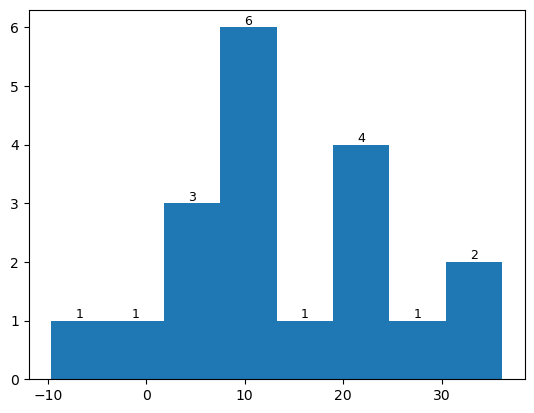

In [35]:
import matplotlib.pyplot as plt

data = cumulative_error.values()  # your 1D array/list

counts, bins, patches = plt.hist(data, bins=8)

for p in patches:
    h = p.get_height()
    if h == 0:
        continue
    x = p.get_x() + p.get_width() / 2
    plt.text(x, h, f"{int(h)}", ha="center", va="bottom", fontsize=9)

plt.show()

In [36]:
cumulative_error

{1: 22.49539676131916,
 2: 9.337181185533714,
 3: 10.834216105049537,
 4: 5.5192855623143116,
 5: 17.272134435629702,
 8: 22.743862657137136,
 9: 9.874225785359762,
 10: 2.9208991031486056,
 11: 11.77581687185779,
 12: 9.54831621986151,
 15: 11.90426062072063,
 18: -0.272965022448557,
 19: 26.133905536634384,
 22: 36.13727031470011,
 25: 22.654511453520776,
 27: 21.158463973663153,
 28: 31.430643379639246,
 29: -9.674224113956448,
 30: 5.551170557538085}

Text(0, 0.5, 'Daily Calculated Energy Factor')

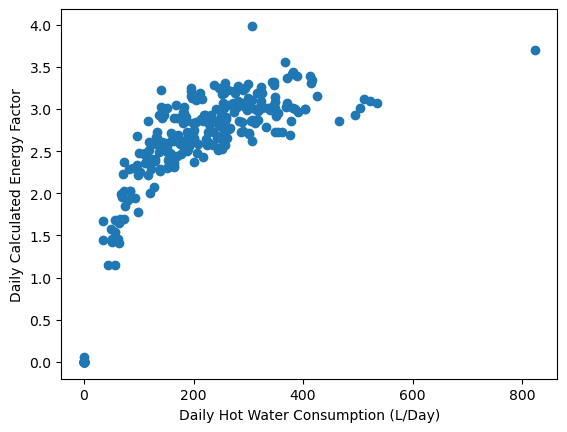

In [86]:
import matplotlib.pyplot as plt

plt.scatter(daily_flow, daily_delivered/daily_electric)
plt.xlabel("Daily Hot Water Consumption (L/Day)")
plt.ylabel("Daily Calculated Energy Factor")

In [46]:
ground_pwr[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1)


AttributeError: 'Series' object has no attribute 'reshape'

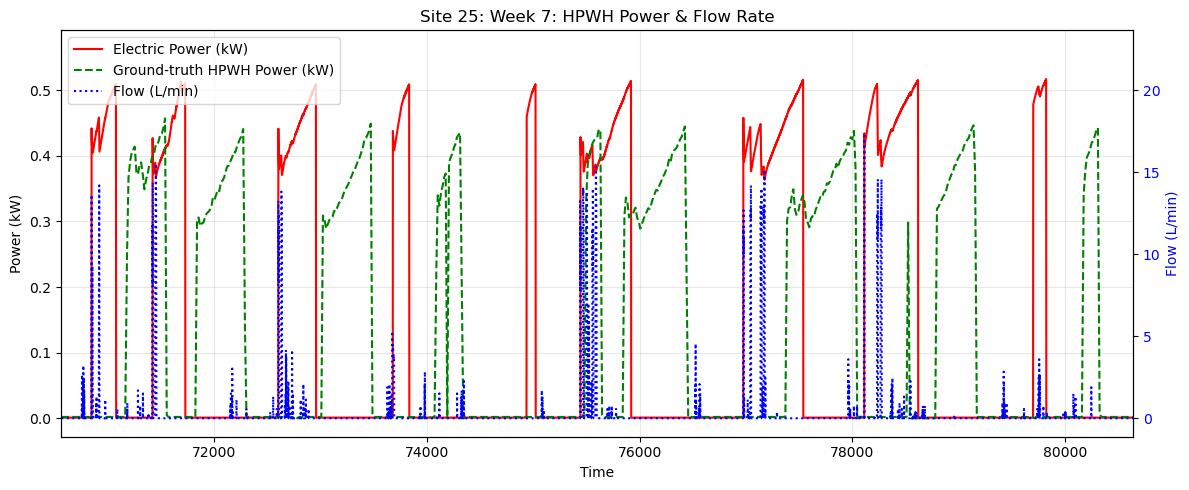

In [113]:
setpoint = 48.9
site_number = 25
MINUTES_PER_DAY = 24 * 60


data = pd.read_csv(f"120V_site_output\\output_site_120V_{site_number}_(L)_{setpoint}.csv") #output data
data_ground = pd.read_csv(f'..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site_number}.csv') #ground truth
data_raw = pd.read_csv(f'120V_site_raw\site_{site_number}.csv')      
flow_raw = pd.read_csv(f'..\\ochre\\defaults\\Input Files\\120V_Flow\\net_flow_{site_number}_120V.csv')


#Trim outputted data
daily_flow      = data['Draw Data'].values
daily_delivered = data['Hot Water Delivered (kW)'].values
electric  = data['Water Heating Electric Power (kW)'].values
ground_pwr = data_ground['HPWH_pwr_kW'].values

# Trim to a multiple of 1440 (drops incomplete trailing day)
n_days = len(daily_flow) // MINUTES_PER_DAY
n_days = n_days#


daily_flow      = daily_flow[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1)
daily_delivered = daily_delivered[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
daily_electric  = electric[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
ground_kwh = ground_pwr[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60


flow = data_ground['flow_L_per_min']


import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

day = 0
week = 7
month = 0
data_len = len(data.index)

fig, ax1 = plt.subplots(figsize=(12, 5))

# Primary axis - power variables

#ax1.plot(data_backup.index, backup_pwr, color='orange', label='Hot Water Delivered (kW)')
ax1.plot(data.index, data['Water Heating Electric Power (kW)'], color='red', label='Electric Power (kW)')
ax1.plot(data.index, ground_pwr[0:data_len], color='green', label='Ground-truth HPWH Power (kW)', linestyle='dashed')
ax1.set_ylabel('Power (kW)')
ax1.set_xlabel('Time')
ax1.grid(True, alpha=0.3)

# Secondary axis - flow
ax2 = ax1.twinx()
ax2.plot(data.index, data['Draw Data'], color='blue', label='Flow (L/min)', linestyle='dotted')
ax2.set_ylabel('Flow (L/min)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_xlim(week * 7 * MINUTES_PER_DAY, week * 7 * MINUTES_PER_DAY +  7 * MINUTES_PER_DAY)

plt.title(f'Site {site_number}: Week {week}: HPWH Power & Flow Rate')

# ax1.set_xlim(month * 30 * MINUTES_PER_DAY, month * 30 *  MINUTES_PER_DAY +   30 * MINUTES_PER_DAY)

# plt.title(f'Site {site_number}: Month {month}: HPWH Power & Flow Rate')

plt.tight_layout()
plt.show()

# Daily Aggregates


C:\Users\m10950449\AppData\Local\Temp\ipykernel_58544\3687483461.py:8: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'120V_site_raw\site_{site_number}.csv')


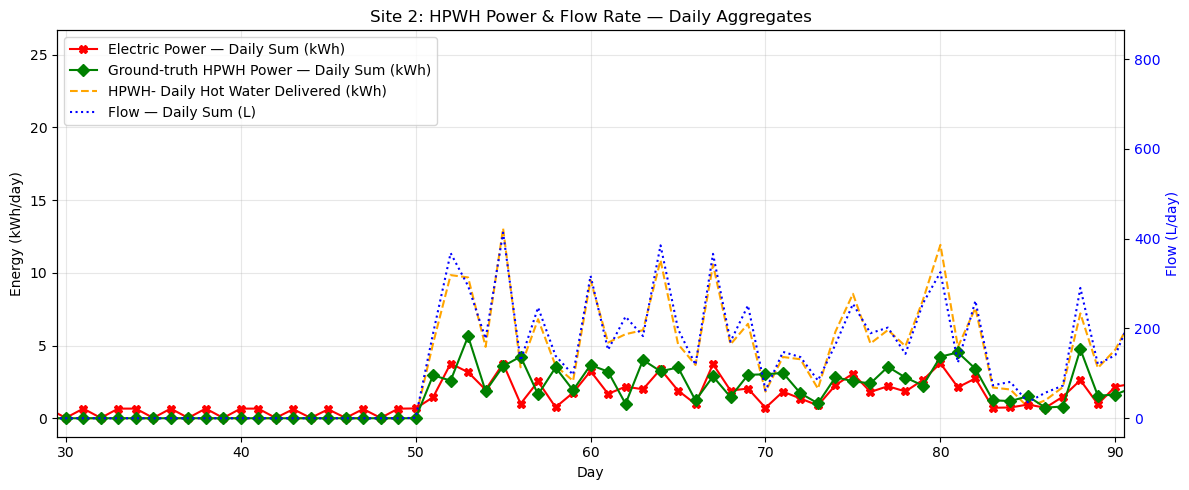

In [121]:
setpoint = 48.9
site_number = 2
MINUTES_PER_DAY = 24 * 60


data = pd.read_csv(f"120V_site_output\\output_site_120V_{site_number}_(L)_{setpoint}.csv") #output data
data_ground = pd.read_csv(f'..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site_number}.csv') #ground truth
data_raw = pd.read_csv(f'120V_site_raw\site_{site_number}.csv')      
flow_raw = pd.read_csv(f'..\\ochre\\defaults\\Input Files\\120V_Flow\\net_flow_{site_number}_120V.csv')


#Trim outputted data
daily_flow      = data['Draw Data'].values
daily_delivered = data['Hot Water Delivered (kW)'].values
electric  = data['Water Heating Electric Power (kW)'].values
ground_pwr = data_ground['HPWH_pwr_kW'].values

# Trim to a multiple of 1440 (drops incomplete trailing day)
n_days = len(daily_flow) // MINUTES_PER_DAY
n_days = n_days#


daily_flow      = daily_flow[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1)
daily_delivered = daily_delivered[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
daily_electric  = electric[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
ground_kwh = ground_pwr[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60


flow = data_ground['flow_L_per_min']

import pandas as pd
import matplotlib.pyplot as plt

day = 0
week = 0
month = 1
data_len = len(data.index)

# --- Aggregate to daily sums ---
MINUTES_PER_DAY = 1440


# Filter to the selected month
day_start = month * 30
day_end   = day_start + 60

days_index = range(len(daily_electric))


fig, ax1 = plt.subplots(figsize=(12, 5))

# Primary axis - power (daily sums)
ax1.plot(days_index, daily_electric,   color='red',   label='Electric Power — Daily Sum (kWh)', marker='X',       zorder=3)
ax1.plot(days_index, ground_kwh, color='green', label='Ground-truth HPWH Power — Daily Sum (kWh)',
            marker='D', zorder=3)
ax1.plot(days_index, daily_delivered, label="HPWH- Daily Hot Water Delivered (kWh)", color="orange", linestyle="dashed")
ax1.set_ylabel('Energy (kWh/day)')
ax1.set_xlabel('Day')
ax1.grid(True, alpha=0.3)

# Secondary axis - flow (daily sum)
ax2 = ax1.twinx()
ax2.plot(days_index, daily_flow, color='blue', label='Flow — Daily Sum (L)', linestyle="dotted", zorder=3)
ax2.set_ylabel('Flow (L/day)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_xlim(day_start - 0.5, day_end + 0.5)
plt.title(f'Site {site_number}: HPWH Power & Flow Rate — Daily Aggregates')
plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import pandas as pd

e = elec_daily
g = ground_daily

diff = g - e

def pct(a, p):
    return np.percentile(a, p)

mae  = np.mean(np.abs(diff))
rmse = np.sqrt(np.mean(diff**2))
mape = np.mean(np.abs(diff / (g + 1e-9))) * 100
r2   = 1 - np.sum(diff**2) / np.sum((g - g.mean())**2)

stats = pd.DataFrame({
    'Metric': [
        'Total energy (kWh)',
        'Mean (kWh/day)', 'Std dev', 'Min',
        'Median (p50)', 'p75', 'p90', 'Max',
        '— MAE', '— RMSE', '— MAPE (%)', '— R²',
    ],
    'Simulated': [
        e.sum(),
        e.mean(), e.std(), e.min(),
        pct(e,50), pct(e,75), pct(e,90), e.max(),
        mae, rmse, mape, r2,
    ],
    'Ground truth': [
        g.sum(),
        g.mean(), g.std(), g.min(),
        pct(g,50), pct(g,75), pct(g,90), g.max(),
        None, None, None, None,
    ],
    'Difference (GT − Sim)': [
        g.sum()-e.sum(),
        g.mean()-e.mean(), g.std()-e.std(), g.min()-e.min(),
        pct(g,50)-pct(e,50), pct(g,75)-pct(e,75),
        pct(g,90)-pct(e,90), g.max()-e.max(),
        None, None, None, None,
    ],
}).set_index('Metric')

pd.set_option('display.float_format', '{:.3f}'.format)
print(stats.to_string())

NameError: name 'elec_daily' is not defined

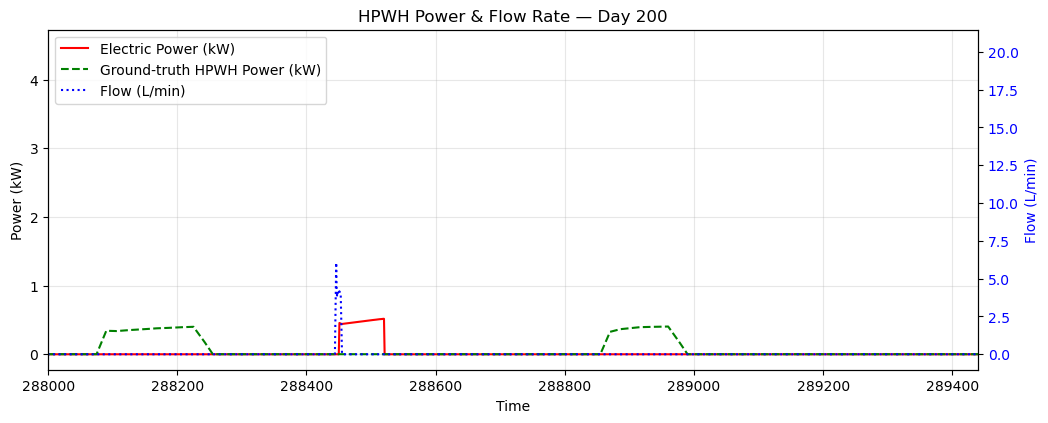

In [90]:
from matplotlib.widgets import Slider
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))
plt.subplots_adjust(bottom=0.2)  # make room for slider

data_len = len(data.index)

def get_xlim(day):
    return day * MINUTES_PER_DAY, day * MINUTES_PER_DAY + MINUTES_PER_DAY

# Initial day
day = 200

line_elec, = ax1.plot(data.index, data['Water Heating Electric Power (kW)'], color='red', label='Electric Power (kW)')
line_ground, = ax1.plot(data.index, ground_pwr[0:data_len], color='green', label='Ground-truth HPWH Power (kW)', linestyle='dashed')
ax1.set_ylabel('Power (kW)')
ax1.set_xlabel('Time')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
line_flow, = ax2.plot(data.index, data['Draw Data'], color='blue', label='Flow (L/min)', linestyle='dotted')
ax2.set_ylabel('Flow (L/min)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_xlim(*get_xlim(day))
title = plt.title(f'HPWH Power & Flow Rate — Day {day}')



In [51]:
#2 node simulation
import os
import datetime as dt
import pandas as pd
import numpy as np

from ochre import Dwelling
from ochre.utils import default_input_path  # for using sample files
from ochre import HeatPumpWaterHeater

import datetime as dt
start_date = dt.datetime(2013, 2, 5, 0, 0) 
setpoint_default = 51  # in C #alternate b/w 60 and 49
deadband_default = 5.56  # in C

def predict_two_node(temp_n1, temp_n2, setpoint, draw):
    setpoint_default = setpoint
    equipment_args = {
        "start_time": start_date,  # year, month, day, hour, minute
        "time_res": dt.timedelta(minutes=1),
        "duration": dt.timedelta(minutes = len(draw)),
        "verbosity": 9,  # required to get setpoint and deadband in results
        "save_results": False,  # if True, must specify output_path
        # "output_path": os.getcwd(),        # Equipment parameters
        "Setpoint Temperature (C)": setpoint_default,
        "Tank Volume (L)": 250,
        "Tank Height (m)": 1.22,
        "UA (W/K)": 2.17,
        "HPWH COP (-)": 4.5,
        "water_nodes": 2
    }

    # Create water draw schedule
    times = pd.date_range(
        equipment_args["start_time"],
        equipment_args["start_time"] + equipment_args["duration"],
        freq=equipment_args["time_res"],
        inclusive="left",
    )
    #withdraw_rate = np.random.choice([0, water_draw_magnitude], p=[0.99, 0.01], size=len(times))
    withdraw_rate = draw
    withdraw_rate = withdraw_rate[:len(times)]
    schedule = pd.DataFrame(
        {
            "Water Heating (L/min)": withdraw_rate,
            "Water Heating Setpoint (C)": setpoint_default,  # Setting so that it can reset
            "Water Heating Deadband (C)": deadband_default,  # Setting so that it can reset
            "Zone Temperature (C)": 20,
            "Zone Wet Bulb Temperature (C)": 15,  # Required for HPWH
            "Mains Temperature (C)": 7,
        },
        index=times,
    )

    # Initialize equipment
    hpwh = HeatPumpWaterHeater(schedule=schedule, **equipment_args)

    hpwh.model.states[:] = np.array([temp_n1, temp_n2])

    # Simulate
    data = pd.DataFrame()
    data = {'draw_data' :[], 'setpoint' :[]}
    control_signal = {}
    setpoints = []

    for t in hpwh.sim_times:
        # Change setpoint based on hour of day
        setpoint = setpoint_default
        control_signal = {
            "Setpoint": setpoint
        }

        setpoints.append(setpoint)
        # Run with controls
        _ = hpwh.update(control_signal=control_signal)

    
    df = hpwh.finalize()

    cols_to_save = [
        "Hot Water Outlet Temperature (C)",
        "T_WH1",
        "T_WH2"
    ]

    to_save = df.loc[:, cols_to_save]
    to_save = to_save[14::15] #Get every 15 minutes
    to_save = to_save[:-1]

    #return to_save
    return to_save["Hot Water Outlet Temperature (C)"]


In [52]:
#node_2_temps = predict_two_node(n1, n2, setpoint[0], draw)

test_index = 259393
two_week_minutes = 20160

#Get raw flow data 
raw_flow = pd.read_csv("..\\ochre\\defaults\\Input Files\\net_flow_90023.csv")
two_week_data = raw_flow[259393 - 20160: ] #Get 2 weeks before starting value
two_week_data["Flow"] = raw_flow[259393 - 20160: ]
raw_flow = raw_flow[259393:]
two_week_data.reset_index(drop=True)



C:\Users\janel\AppData\Local\Temp\ipykernel_24024\175117761.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  two_week_data["Flow"] = raw_flow[259393 - 20160: ]


,0.0,Flow
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
130857,0.0,0.0
130858,0.0,0.0
130859,0.0,0.0
130860,0.0,0.0


In [66]:
#interactable slider
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from ipywidgets import interact

def plot_prediction(days=0, hours=0):
    start_time = pd.to_datetime("2013-05-29 01:22:00") #Start of training data
    
    lower = 96 * days + 4 * hours
    upper = lower + 8
    data_range = np.arange(lower, upper)

    # convert time interval
    tick_indices = np.arange(lower, upper)
    tick_labels = pd.to_datetime(tick_indices * 15, unit="m").strftime("%H:%M")

    fig, ax1 = plt.subplots()

    # get predictions
    node_12_temps = node_12["Hot Water Outlet Temperature (C)"][lower:upper]
    n1 = node_12["T_WH3"][lower]
    n2 = node_12["T_WH10"][lower]
    setpoint = node_12["Setpoint"]
    draw = node_12["Draw Data"][lower:upper]
    out = np.zeros(len(draw) * 16,)
    out[::16] = draw

    # Try using raw draw instead
    out = raw_flow[lower*15:lower*15 + 120].to_numpy().flatten()

    node_2_temps = predict_two_node(n1, n2, setpoint[0], out).values
    node_2_temps = np.insert(node_2_temps, 0, node_12_temps.reset_index(drop=True)[0])

    current_time = start_time + pd.Timedelta(minutes=lower)
    nth_flow = get_nth_flow(current_time)
    node_2_99 = predict_two_node(n1, n2, setpoint[0], nth_flow)
    node_2_99 = np.insert(node_2_99, 0, node_12_temps.reset_index(drop=True)[0])

    rolling_flow = get_rolling_flow_avg(two_week_data[lower:lower + two_week_minutes], current_time)
    node_2_week = predict_two_node(n1, n2, setpoint[0], rolling_flow)
    node_2_week = np.insert(node_2_week, 0, node_12_temps.reset_index(drop=True)[0])

    # plotting

    ax1.plot(data_range, node_12_temps * 9/5 + 32, label="12-Node Model", color="tab:red")
    #ax1.plot(data_range, node_2_99 * 9/5 + 32, label="99th Percentile Forecasting", color="green")
    ax1.plot(data_range, node_2_week * 9/5 + 32, label="2 Week Forecasting", color="orange", linestyle='dashed')
    ax1.plot(data_range, node_2_temps * 9/5 + 32, label="2-Node Perfect Forecasting", color="purple", linestyle='dashdot')
    ax1.set_xlabel("Time of Day (HH:MM)")
    ax1.set_ylabel("Hot Water Outlet Temperature (°F)", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:red")

    ax1.set_xticks(tick_indices[::4])
    ax1.set_xticklabels(tick_labels[::4], rotation=45)
    ax1.set_title("Prediction Comparison")

    # secondary axis (Draw Data)
    ax2 = ax1.twinx()
    ax2.plot(data_range, node_12["Draw Data"][lower:upper] * 0.264172,
             label="Draw Data", linestyle='dotted', color="tab:blue")
    ax2.set_ylabel("Draw Data (gal)", color="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:blue")
    ax2.set_ylim(0, 50)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    #ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    fig.tight_layout()
    plt.show()

# Create sliders: days (0–20), hours (0–24)
interact(plot_prediction, days=(0, 20), hours=(0, 24, 1))


interactive(children=(IntSlider(value=0, description='days', max=20), IntSlider(value=0, description='hours', …

<function __main__.plot_prediction(days=0, hours=0)>

2026-03-04 17:06:48.854405 - Heat Pump Water Heater at 2013-02-05 00:00:00: Initializing Heat Pump Water Heater (OCHRE v0.8.5)
2026-03-04 17:06:48.875944 - Heat Pump Water Heater at 2013-02-05 02:00:00: Simulation complete, time series results saved in memory (not to a file)
2026-03-04 17:06:48.918441 - Heat Pump Water Heater at 2013-02-05 00:00:00: Initializing Heat Pump Water Heater (OCHRE v0.8.5)
2026-03-04 17:06:48.931640 - Heat Pump Water Heater at 2013-02-05 02:00:00: Simulation complete, time series results saved in memory (not to a file)
2026-03-04 17:06:48.977361 - Heat Pump Water Heater at 2013-02-05 00:00:00: Initializing Heat Pump Water Heater (OCHRE v0.8.5)
2026-03-04 17:06:48.988381 - Heat Pump Water Heater at 2013-02-05 02:00:00: Simulation complete, time series results saved in memory (not to a file)


C:\Users\janel\AppData\Local\Temp\ipykernel_24024\2643447451.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  two_weeks['readTime'] = pd.date_range(start=current_date, periods=len(two_weeks), freq="T")
C:\Users\janel\AppData\Local\Temp\ipykernel_24024\2643447451.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  two_weeks['readTime'] = pd.date_range(start=current_date, periods=len(two_weeks), freq="T")
C:\Users\janel\AppData\Local\Temp\ipykernel_24024\2643447451.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

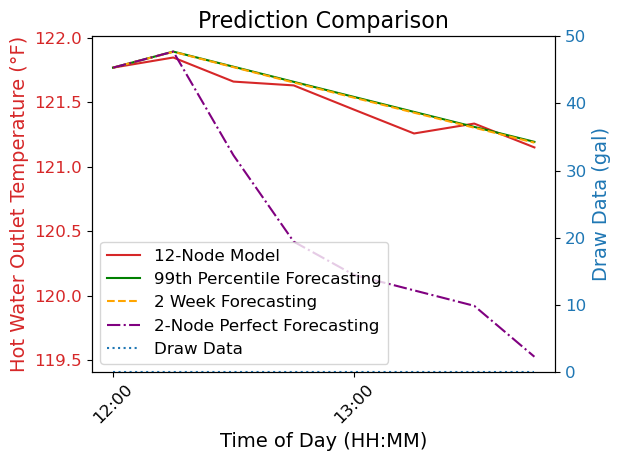

In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

start_time = pd.to_datetime("2013-05-29 01:22:00") #Start of training data


days = 15
hours = 12
lower =  96 * days + 4 * hours    # day value * 96
upper = lower + 8
data_range = np.arange(lower, upper)

# convert time interval
tick_indices = np.arange(lower, upper)  # all 96 intervals
# Map intervals to minutes of day (interval index * 15 min, modulo 1440 for wrapping)
tick_labels = pd.to_datetime(tick_indices * 15, unit="m").strftime("%H:%M")

fig, ax1 = plt.subplots()

#get predictions
node_12_temps = node_12["Hot Water Outlet Temperature (C)"][lower:upper]
n1 = node_12["T_WH3"][lower]
n2 = node_12["T_WH10"][lower]
setpoint = node_12["Setpoint"]
draw = node_12["Draw Data"][lower:upper]
out = np.zeros(len(draw) * 16,)
# Place elements every 16th spot
out[::16] = draw

#Try using raw draw instead
out = raw_flow[lower*15:lower*15 + 120].to_numpy().flatten()


node_2_temps = predict_two_node(n1, n2, setpoint[0], out) #n1, n2, setpoint, draw
node_2_temps = node_2_temps.values
node_2_temps = np.insert(node_2_temps, 0, node_12_temps.reset_index(drop=True)[0])

#Get percentiles
current_time = start_time + pd.Timedelta(minutes=lower)
nth_flow = get_nth_flow(current_time)
node_2_99 = predict_two_node(n1, n2, setpoint[0], nth_flow)
node_2_99 = np.insert(node_2_99, 0, node_12_temps.reset_index(drop=True)[0])

#Get rolling average

rolling_flow = get_rolling_flow_avg(two_week_data[lower:lower + two_week_minutes], current_time)
node_2_week = predict_two_node(n1, n2, setpoint[0], rolling_flow)
node_2_week = np.insert(node_2_week, 0, node_12_temps.reset_index(drop=True)[0])

# primary axis (temperature)
ax1.plot(
    data_range,
    node_12_temps * 9/5 + 32,
    label="12-Node Model",
    color="tab:red"
)

ax1.plot(data_range, node_2_99 * 9/5 + 32, label="99th Percentile Forecasting", color="green")
ax1.plot(data_range, node_2_week * 9/5 + 32, label="2 Week Forecasting",color="orange", linestyle='dashed')
ax1.plot(data_range, node_2_temps * 9/5 + 32, label="2-Node Perfect Forecasting", color="purple", linestyle='dashdot')
ax1.set_xlabel("Time of Day (HH:MM)")
ax1.set_ylabel("Hot Water Outlet Temperature (°F)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax1.set_xticks(tick_indices[::4])
ax1.set_xticklabels(tick_labels[::4], rotation=45)
ax1.set_title("Prediction Comparison")

# secondary axis (Draw Data)
ax2 = ax1.twinx()
ax2.plot(
    data_range,
    node_12["Draw Data"][lower:upper] * 0.264172,  # Convert L to gallons
    label="Draw Data",linestyle='dotted',
    color="tab:blue"
)
ax2.set_ylabel("Draw Data (gal)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")
ax2.set_ylim(0, 50)

# legends combined from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

fig.tight_layout()
plt.show()


In [43]:
node_12['Draw Data'].idxmax()

1503

In [ ]:
two_weeks["hour"] = two_weeks["readTime"].dt.hour
two_weeks

,0.0,readTime,is_weekend,hour
240621,0.0,2013-05-29 01:22:00,False,1
240622,0.0,2013-05-29 01:23:00,False,1
240623,0.0,2013-05-29 01:24:00,False,1
240624,0.0,2013-05-29 01:25:00,False,1
240625,0.0,2013-05-29 01:26:00,False,1
...,...,...,...,...
260776,0.0,2013-06-12 01:17:00,False,1
260777,0.0,2013-06-12 01:18:00,False,1
260778,0.0,2013-06-12 01:19:00,False,1
260779,0.0,2013-06-12 01:20:00,False,1


In [55]:
def get_rolling_flow_avg(data, current_date, horizon = 2):# needs to receive previous two weeks of flow data, data should contain previous flow
    # Select current 2-week slice
    day_minutes = 60 * 24
    hour = current_date.hour
    minute = current_date.minute
    is_weekend = current_date.weekday() >= 5 #if is weekend

    two_weeks = data[:day_minutes * 14]
    two_weeks['readTime'] = pd.date_range(start=current_date, periods=len(two_weeks), freq="T")
    two_weeks["is_weekend"] = two_weeks["readTime"].dt.weekday >= 5
    two_weeks["hour"] = two_weeks["readTime"].dt.hour
    two_weeks = two_weeks.groupby(['hour', 'is_weekend'])['Flow'].mean().reset_index()

    predicted_flow = []
    h_offset = 0
    for i in range(horizon * 60):  # per-minute intervals in number of hours
            total_minutes = minute + i
            h_offset = total_minutes // 60
            current_hour = (hour + h_offset) % 24

            flow = two_weeks.loc[
                (two_weeks['hour'] == current_hour) &
                (two_weeks['is_weekend'] == is_weekend),
                'Flow'
            ]

            if not flow.empty:
                predicted_flow.append(flow.iloc[0] / 60)  # convert hourly flow to per-minute
            else:
                predicted_flow.append(0)  # or np.nan

    return predicted_flow

#get ninety-ninth percentile
raw_data = pd.read_csv("raw_data\\90023_raw.csv")
raw_data["readTime"] = pd.to_datetime(raw_data["readTime"])
raw_data = raw_data[raw_data["readTime"] > pd.Timestamp("2013-01-01")]
nth_percentile = 99 

# Convert flow to liters
raw_data["Flow"] = raw_data["Flow"] * 3.78541

interval = int(len(raw_data)*0.8)
train = raw_data[0:interval] 
train["isWeekend"] = train["readTime"].dt.weekday >= 5 #separate out df by weekends

#compute 99th percentile
train = train[["Flow", "hour", "isWeekend"]]
percentile = train.groupby(['hour', 'isWeekend'])['Flow'].quantile(nth_percentile*0.01).reset_index()

def get_nth_flow(timeStamp, horizon=2, percentiles = percentile):
    #Given a timeStamp, compute predicted flow data for horizon
    hour = timeStamp.hour
    is_weekend = timeStamp.weekday() >= 5
    minute = timeStamp.minute

    predicted_flow = []
    h_offset = 0
    for i in range(horizon * 60):  # loop minute-by-minute for the horizon
        # Update hour offset if minutes overflow
        total_minutes = minute + i
        h_offset = total_minutes // 60
        current_minute = total_minutes % 60

        flow = percentiles.loc[
            (percentiles['hour'] == (hour + h_offset) % 24) &
            (percentiles['isWeekend'] == is_weekend),
            'Flow'
        ]

        if not flow.empty:
            predicted_flow.append(flow.iloc[0] / 60)  # divide hourly flow into per-minute value
        else:
            predicted_flow.append(0)  # or np.nan

    return predicted_flow



C:\Users\janel\AppData\Local\Temp\ipykernel_24024\2643447451.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train["isWeekend"] = train["readTime"].dt.weekday >= 5 #separate out df by weekends


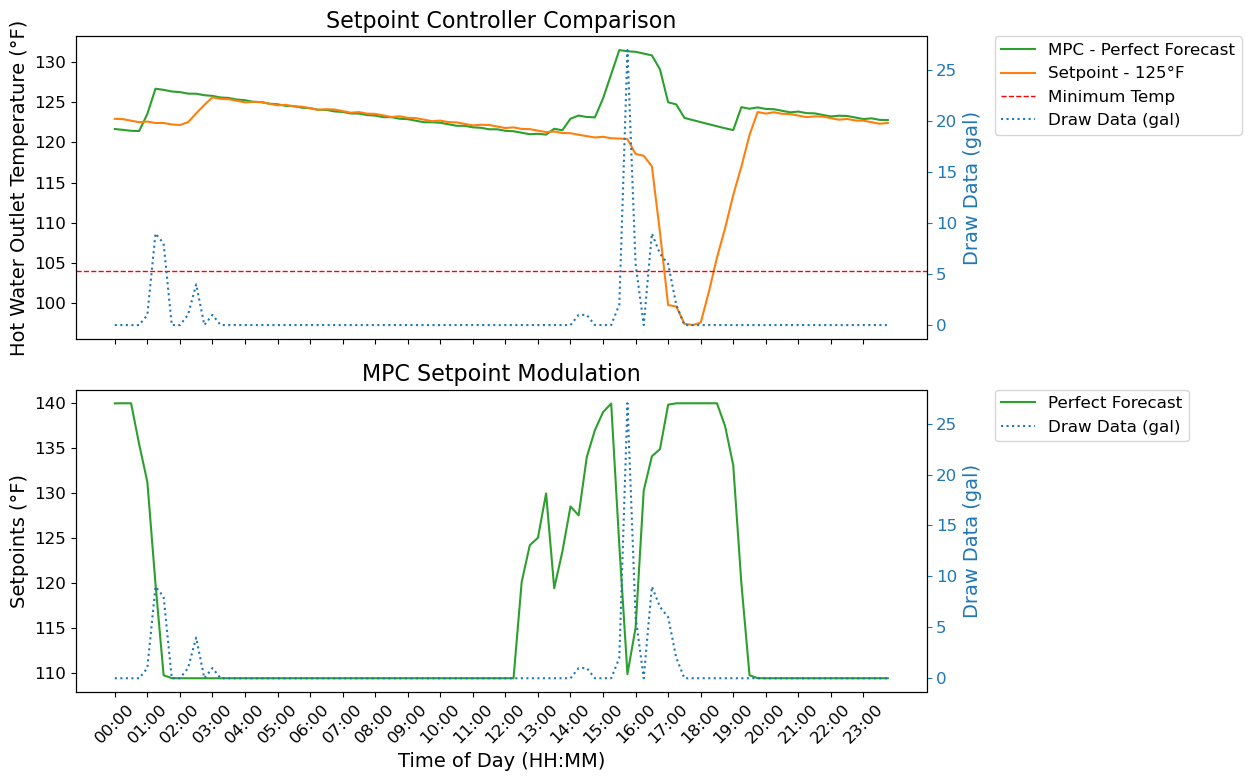

In [9]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
site_number = 90023
water_nodes = 12
setpoint_temp = 51.0
bisection_temp = 49
data_control = pd.read_csv(f'constant_setpoint_90023\\output_site_90023_51_5.56_12.csv')
data_rolling = pd.read_csv(f'bisection_output\\output_site_90023_bisectioncontrol_ud_{bisection_temp}_12_rolling avg.csv')
data_perfect = pd.read_csv(f"bisection_output\\output_site_90023_bisectioncontrol_ud_{bisection_temp}_12_perfect.csv")

lower = (96) * 15  # day value * 96
upper = lower + 96
data_range = np.arange(lower, upper)

# Convert time interval
tick_indices = np.arange(lower, upper)
tick_minutes = ((tick_indices - lower) * 15) % 1440
tick_labels = pd.to_datetime(tick_minutes, unit="m").strftime("%H:%M")

fig, (ax3, ax1) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))

# Global font sizes
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

# ---- Top plot: Temperature + Draw Data overlay ----
display_value = "Hot Water Outlet Temperature (C)"
ax3.set_title("Setpoint Controller Comparison")
ax3.set_xticks(tick_indices[::4])
ax3.set_xticklabels(tick_labels[::4], rotation=45)
ax3.set_ylabel("Hot Water Outlet Temperature (°F)")

# # line1, = ax3.plot(data_range, data_rolling[display_value][lower:upper] * 9/5 + 32, label="Rolling Avg")
line2, = ax3.plot(data_range, data_perfect[display_value][lower:upper] * 9/5 + 32, label="MPC - Perfect Forecast", color="tab:green")
line3, = ax3.plot(data_range, data_control[display_value][lower:upper] * 9/5 + 32, label=f"Setpoint - 125°F", color='tab:orange')
line4 = ax3.axhline(y=40 * 9/5 + 32, color='r', linestyle='--', linewidth=1, label='Minimum Temp')

# Secondary y-axis for Draw Data on ax3
ax3_twin = ax3.twinx()
line5, = ax3_twin.plot(
    data_range,
    data_control['Draw Data'][lower:upper] * 0.264172,
    label="Draw Data (gal)",
    linestyle="dotted",
    color="tab:blue",
    alpha=1
)
ax3_twin.set_ylabel("Draw Data (gal)", color="tab:blue")
ax3_twin.tick_params(axis='y', colors="tab:blue")

# Combined legend for ax3 — placed to the right outside
temp_lines = [line2, line3, line4, line5]
temp_labels = [l.get_label() for l in temp_lines]
ax3.legend(temp_lines, temp_labels, loc="upper left", bbox_to_anchor=(1.08, 1.0), borderaxespad=0)

# ---- Bottom plot: Setpoints ----
display_value = "Setpoints"
ax1.set_xticks(tick_indices[::4])
ax1.set_xticklabels(tick_labels[::4], rotation=45)
ax1.set_ylabel("Setpoints (°F)")
ax1.set_xlabel("Time of Day (HH:MM)")

# Secondary y-axis for Draw Data on ax1
ax1_twin = ax1.twinx()
line_draw2, = ax1_twin.plot(
    data_range,
    data_control['Draw Data'][lower:upper] * 0.264172,
    label="Draw Data (gal)",
    linestyle="dotted",
    color="tab:blue",
    alpha=1
)
ax1_twin.set_ylabel("Draw Data (gal)", color="tab:blue", fontsize=14)
ax1_twin.tick_params(axis='y', colors="tab:blue")

# sp_line1, = ax1.plot(data_range, data_rolling[display_value][lower:upper] * 9/5 + 32, label="Rolling Avg")
sp_line2, = ax1.plot(data_range, data_perfect[display_value][lower:upper] * 9/5 + 32, label="Perfect Forecast", color="tab:green")
sp_lines = [sp_line2, line_draw2]
sp_labels = [l.get_label() for l in sp_lines]
ax1.legend(sp_lines, sp_labels, loc="upper left", bbox_to_anchor=(1.08, 1.0), borderaxespad=0)
ax1.set_xlabel("Time of Day (HH:MM)")
ax1.set_title("MPC Setpoint Modulation")

# Adjust layout to make room for side legends
plt.tight_layout()
fig.subplots_adjust(right=0.78)
plt.show()

In [36]:
# ---- Bottom plot: Setpoints ----
display_value = "Setpoints"
ax1.set_xticks(tick_indices[::4])
ax1.set_xticklabels(tick_labels[::4], rotation=45)
ax1.set_ylabel("Setpoints (°F)")
ax1.set_xlabel("Time of Day (HH:MM)")

# Secondary y-axis for Draw Data on ax1
ax1_twin = ax1.twinx()
line_draw2, = ax1_twin.plot(
    data_range,
    data_control['Draw Data'][lower:upper] * 0.264172,
    label="Draw Data (G)",
    linestyle="dotted",
    color="tab:blue",
    alpha=1
)
ax1_twin.set_ylabel("Draw Data (gallons)", color="tab:blue", fontsize=14)
ax1_twin.tick_params(axis='y', colors="tab:blue")

# sp_line1, = ax1.plot(data_range, data_rolling[display_value][lower:upper] * 9/5 + 32, label="Rolling Avg")
sp_line2, = ax1.plot(data_range, data_perfect[display_value][lower:upper] * 9/5 + 32, label="Perfect Forecast", color="tab:green")
sp_lines = [sp_line2, line_draw2]
sp_labels = [l.get_label() for l in sp_lines]
ax1.legend(sp_lines, sp_labels, loc="upper left", bbox_to_anchor=(1.08, 1.0), borderaxespad=0)


In [ ]:

#Compare overall water heater runtime
arr = pd.read_csv(f'site_output\\output_site_{site_number}_151(L)_60.csv')
runtime = [np.sum(arr['Water Heating Mode'] == 'Heat Pump On')*15]
runtime


17010

In [37]:
import pandas as pd
import numpy as np

def get_daily_kWh(data):
    energy = data["Water Heating Electric Power"] #15 minute intervals of kwh
    day_sums = energy.groupby(energy.index // 96).sum().tolist()
    return (np.mean(day_sums))

def get_net_kWh(data):
    energy = data["Water Heating Electric Power"] #15 minute intervals of kwh
    return (np.sum(energy))


def return_unmet_draws(data, min = 40.6):
    #data["Hot Water Outlet Temperature (C)"] = (pd.to_numeric(data["Hot Water Outlet Temperature (C)"], errors="coerce"))
    #draws = data["Hot Water Outlet Temperature (C)"].values
    #cold_water_draws = sum(float(i) < min for i in draws)
    #return cold_water_draws/len(draws) * 100
    return (data["Hot Water Unmet Demand (kWh)"].sum())

def get_runtime(data):
    return np.sum(data['Water Heating Mode'] == 'Heat Pump On')*15

sites_60 = [90159, 22096, 13438, 11531, 23744,
11289,
13265,
23666,
90028,
90050,
90135,
10441,
90015,
90030
]

sites_80 = [21578, 22897, 90023, 90130, 99094, 90051, 90069, 90131, 90034]
sites_50 = [99148, 99162, 99103, 99092, 99084] 


sites = [ 22096, 13438, 11531, 23744,
11289,
13265,
23666,
90028,
90050,
90135,
10441,
90015,
90030, 21578, 22897, 90023, 90130, 99094, 90051, 90069, 90131, 90034, 99148, 99162, 99103, 99092, 99084
]

unmet_draws = []
daily_kWh = []
net_savings = []
avg_draw = []
heating_mode = []
net_kWh = []
for site_number in sites:
    print(site_number)
    #Comparing standard performance to 40 G bisection controller

    min_temp = 40.6
    baseline_40 = pd.read_csv(f'site_output\\output_site_{site_number}_151(L)_51.5.csv')
    elevated = pd.read_csv(f'site_output\\output_site_{site_number}_151(L)_60.csv')

    files = [
        f'site_output\\output_site_{site_number}_227(L)_51.5.csv',
        f'site_output\\output_site_{site_number}_303(L)_51.5.csv',
        f'site_output\\output_site_{site_number}_189(L)_51.5.csv'
    ]

    baseline_og = None

    for file in files:
        try:
            baseline_og = pd.read_csv(file)
            print("Loaded:", file)
            break
        except FileNotFoundError:
            pass

    if baseline_og is None:
        raise FileNotFoundError("None of the baseline files exist.")

    bisection = pd.read_csv(f"site_output\\output_site_{site_number}_bisectioncontrol_ud_49_12_rolling avg.csv")

    print("Baseline (OG) ", return_unmet_draws(baseline_og, min_temp), get_daily_kWh(baseline_og), np.sum(baseline_og["Water Heating Electric Power"])) #365 days
    print("Baseline (40g): ", return_unmet_draws(baseline_40, min_temp), get_daily_kWh(baseline_40), np.sum(baseline_40["Water Heating Electric Power"])) #365 days
    print("Bisection", return_unmet_draws(bisection, min_temp), get_daily_kWh(bisection), np.sum(bisection["Water Heating Electric Power"])) #100 days
    print("Baseline (Elevated) ", return_unmet_draws(elevated, min_temp), get_daily_kWh(elevated), np.sum(elevated["Water Heating Electric Power"])) #365 days
    print("Net savings: ", 1 - np.sum(bisection["Water Heating Electric Power"])/np.sum(elevated["Water Heating Electric Power"]))

    draw = baseline_og['Draw Data']
    draw = draw[:-95] #removing last day to keep indices exact
    daily_avg = np.sum(np.asarray(draw).reshape(-1, 96), axis=1)
    avg_draw.append(daily_avg.mean()) #avg L per day
    unmet_draws.append([return_unmet_draws(baseline_og, min_temp),return_unmet_draws(baseline_40, min_temp),return_unmet_draws(elevated, min_temp), return_unmet_draws(bisection, min_temp) ])
    daily_kWh.append([get_daily_kWh(baseline_og), get_daily_kWh(baseline_40), get_daily_kWh(elevated),get_daily_kWh(bisection)  ])
    net_kWh.append([get_net_kWh(baseline_og), get_net_kWh(baseline_40), get_net_kWh(elevated),get_net_kWh(bisection)  ])
    #gives minutes of runtime for each treatment
    heating_mode.append([get_runtime(baseline_og), get_runtime(baseline_40), get_runtime(elevated), get_runtime(bisection)])
    net_savings.append((1 - np.sum(bisection["Water Heating Electric Power"])/np.sum(elevated["Water Heating Electric Power"])) * 100)
    #print(return_unmet_draws(bisection_ideal, min_temp), get_daily_kWh(bisection_ideal), np.sum(bisection_ideal["Water Heating Electric Power"])) #100 days


# Convert to arrays
avg_draw_arr = np.array(avg_draw)
sites_arr = np.array(sites)
unmet_draws = np.array(unmet_draws)
daily_kWh = np.array(daily_kWh)
net_kWh = np.array(net_kWh)
net_savings = np.array(net_savings)

# ---- Create gallon size array ----
def get_gallon_size(site):
    if site in sites_50:
        return 50
    elif site in sites_60:
        return 60
    elif site in sites_80:
        return 80
    else:
        return 999  # fallback safety

gallon_sizes = np.array([get_gallon_size(s) for s in sites_arr])

# ---- Multi-key sort ----
# First key: gallon size
# Second key: avg draw
sort_idx = np.lexsort((avg_draw_arr, gallon_sizes))

# Apply sorting
avg_draw_arr = avg_draw_arr[sort_idx]
sites_arr = sites_arr[sort_idx]
gallon_sizes = gallon_sizes[sort_idx]
unmet_draws = unmet_draws[sort_idx] #kwH
daily_kWh = daily_kWh[sort_idx] #dialy kWh
net_savings = net_savings[sort_idx]
heating_mode = np.array(heating_mode)[sort_idx]
net_kWh = net_kWh[sort_idx]



 

22096
Loaded: site_output\output_site_22096_227(L)_51.5.csv
Baseline (OG)  0.1864483982841903 2.816526182610909 281.6526182610909
Baseline (40g):  3.043578927284599 2.7573431632439576 275.73431632439576
Bisection 0.43931468790691175 2.8221984548233894 282.2198454823389
Baseline (Elevated)  0.0953402247622213 3.1532539307615974 315.3253930761596
Net savings:  0.10498852398425418
13438
Loaded: site_output\output_site_13438_227(L)_51.5.csv
Baseline (OG)  0.009069298790264399 2.6129379363113117 261.2937936311311
Baseline (40g):  3.3521687661173507 2.568959119207333 256.8959119207332
Bisection 0.0 2.595917143168224 259.5917143168223
Baseline (Elevated)  0.17707857342515804 2.9411453849849334 294.1145384984933
Net savings:  0.11737884280701028
11531
Loaded: site_output\output_site_11531_227(L)_51.5.csv
Baseline (OG)  1.4326800769319632 2.697385664126642 269.73856641266417
Baseline (40g):  3.756966679342849 2.6684751812857685 266.8475181285768
Bisection 0.813321808309329 2.675018790510792 267

In [112]:
daily_kWh 

array([[1.49774456, 1.48234678, 1.76250878, 1.51873472],
       [1.51393714, 1.5043333 , 1.7781416 , 1.52801805],
       [1.64994836, 1.63990757, 1.93040985, 1.65650956],
       [1.81976838, 1.80420223, 2.10200955, 1.82918028],
       [1.91350777, 1.88710053, 2.20594856, 1.93818526],
       [0.81611631, 0.80285657, 1.02837704, 0.85449661],
       [1.00418836, 0.98192511, 1.23234604, 1.06684002],
       [1.01759514, 1.01132438, 1.24838899, 1.03758475],
       [1.20238583, 1.18345968, 1.44707616, 1.22233168],
       [1.20238973, 1.19491979, 1.44988218, 1.23229282],
       [1.37433562, 1.35916344, 1.63334585, 1.40948928],
       [1.55438532, 1.54025948, 1.8178799 , 1.54697746],
       [1.58102701, 1.55222393, 1.83011155, 1.58593129],
       [1.86920881, 1.84123122, 2.15754628, 1.85922122],
       [2.11988292, 2.07030536, 2.41386602, 2.13009463],
       [2.61293794, 2.56895912, 2.94114538, 2.59591714],
       [2.69738566, 2.66847518, 3.04821897, 2.67501879],
       [2.81652618, 2.75734316,

In [111]:
import pandas as pd
import numpy as np

df = pd.DataFrame(unmet_draws, columns=["Baseline (OG)", "Baseline (40g)", "Elevated", "Bisection"])
df["gallon_size"] = gallon_sizes

kWh_df = pd.DataFrame(daily_kWh, columns=["Baseline (OG)", "Baseline (40g)", "Elevated", "Bisection"])
kWh_df["gallon_size"] = gallon_sizes

print(df.groupby("gallon_size")[["Baseline (OG)", "Baseline (40g)", "Elevated", "Bisection"]].sum())
print(kWh_df.groupby("gallon_size")[["Baseline (OG)", "Baseline (40g)", "Elevated", "Bisection"]].mean())

cols = ["Baseline (OG)", "Baseline (40g)", "Elevated", "Bisection"]
# % of sites fully satisfied (unmet == 0) per tank size
satisfaction = df.groupby("gallon_size")[cols].apply(lambda g: (g < 0.1).mean() * 100).round(1)
print("% of Sites Fully Satisfied (zero unmet load)")
print(satisfaction)

             Baseline (OG)  Baseline (40g)    Elevated  Bisection
gallon_size                                                      
50                0.666488        3.879406    0.000000   0.000000
60                3.324788       30.990321    3.482387   1.837753
80               38.547303      235.157027  100.890241  73.397279
             Baseline (OG)  Baseline (40g)  Elevated  Bisection
gallon_size                                                    
50                1.678981        1.663578  1.955804   1.694126
60                1.682182        1.656342  1.953957   1.695261
80                2.526725        2.424912  2.804229   2.501272
% of Sites Fully Satisfied (zero unmet load)
             Baseline (OG)  Baseline (40g)  Elevated  Bisection
gallon_size                                                    
50                    80.0            40.0     100.0      100.0
60                    61.5            23.1      69.2       76.9
80                    33.3            11.1      1

In [113]:
df

,Baseline (OG),Baseline (40g),Elevated,Bisection,gallon_size
0,0.000000,0.350998,0.000000,0.000000,50
1,0.000000,0.120938,0.000000,0.000000,50
2,0.000000,0.001962,0.000000,0.000000,50
3,0.000000,0.003682,0.000000,0.000000,50
4,0.666488,3.401826,0.000000,0.000000,50
5,0.000000,0.239621,0.000000,0.000000,60
6,0.411208,4.419338,0.461330,0.000000,60
7,0.000000,0.000000,0.000000,0.000000,60
8,0.000000,0.690499,0.012065,0.000000,60
9,0.000000,0.047921,0.000000,0.000000,60


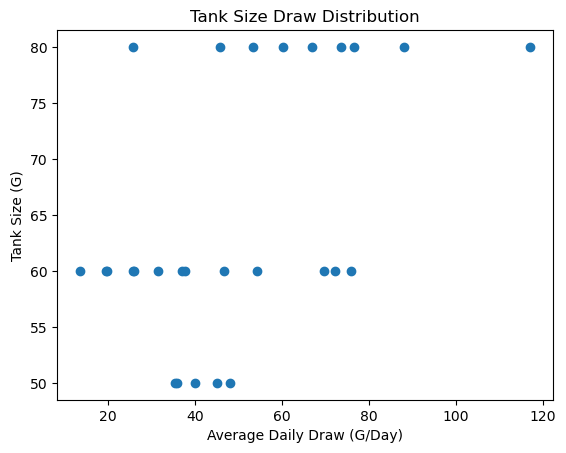

Overall mean draw (G/day): 49.67823086410431
                  mean    variance    std_dev        min        q25  \
gallon_size                                                           
50           40.860579   31.116957   5.578257  35.404017  35.858562   
60           40.743562  455.238559  21.336320  13.505041  25.878771   
80           67.482559  682.509819  26.124889  25.828266  53.373702   

                median        q75         max  count  
gallon_size                                           
50           39.999973  44.959566   48.080776      5  
60           36.959571  54.333297   75.959545     13  
80           66.909046  76.565605  117.070629      9  


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Convert to gallons
avg_draw_g = avg_draw_arr * 0.264172

# Scatter plot
plt.scatter(avg_draw_g , gallon_sizes)
plt.xlabel("Average Daily Draw (G/Day)")
plt.ylabel("Tank Size (G)")
plt.title("Tank Size Draw Distribution")
plt.show()

# Optional: print overall mean draw
print("Overall mean draw (G/day):", np.mean(avg_draw_g))

# Create DataFrame
df = pd.DataFrame({
    "avg_draw": avg_draw_g,
    "gallon_size": gallon_sizes
})

# Group by tank size and compute statistics
grouped_stats = df.groupby("gallon_size")["avg_draw"].agg(
    mean="mean",
    variance=lambda x: np.var(x, ddof=1),
    std_dev=lambda x: np.std(x, ddof=1),
    min="min",
    q25=lambda x: np.percentile(x, 25),
    median="median",
    q75=lambda x: np.percentile(x, 75),
    max="max",
    count="count"
)

print(grouped_stats)

In [4]:
#net_kWh[:,0] - unmet_draws[:,0]
avg_draw_g = avg_draw_arr * 0.264172
avg_draw_g

array([ 35.4040167 ,  35.85856185,  39.99997322,  44.95956586,
        48.08077589,  13.50504146,  19.50503745,  19.79796654,
        25.87877055,  25.89897256,  31.54543343,  36.95957122,
        37.8181565 ,  46.65653442,  54.33329696,  69.63631702,
        72.17166885,  75.95954511,  25.82826554,  45.80805014,
        53.37370164,  60.16157588,  66.90904611,  73.55550631,
        76.56560531,  88.07064811, 117.07062869])

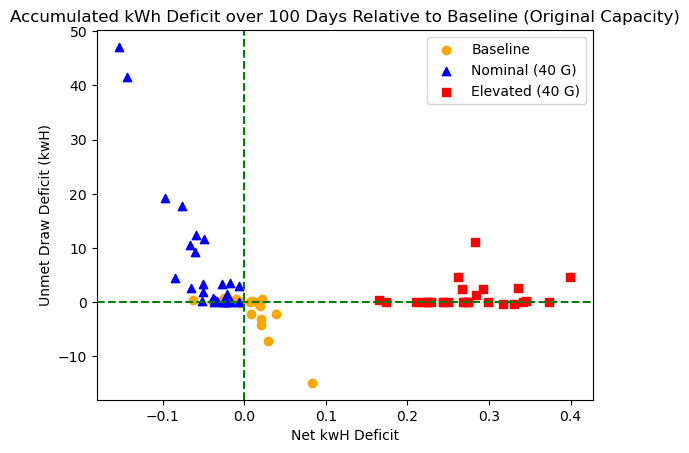

In [ ]:
import matplotlib.pyplot as plt

# plt.scatter(daily_kWh[:,0], unmet_draws[:,0], label="Baseline (OG)", color="orange")
# plt.scatter(daily_kWh[:,1], unmet_draws[:,1], label="Baseline (40g)", color="blue", marker="^")
# plt.scatter(daily_kWh[:,2], unmet_draws[:,2], label="Elevated", color="red", marker="s")
# plt.scatter(daily_kWh[:,3], unmet_draws[:,3], label="Bisection (40g))", color="green", s=20)

#Plot baseline - bisection
plt.scatter(daily_kWh[:,0] - daily_kWh[:,3], unmet_draws[:,0] - unmet_draws[:,3], label="Baseline", color="orange")
#baseline (40) - bisection
plt.scatter(daily_kWh[:,1] - daily_kWh[:,3], unmet_draws[:,1] - unmet_draws[:,3], label="Nominal (40 G)", color="blue", marker="^")
#elevated - bisection
plt.scatter(daily_kWh[:,2] - daily_kWh[:,3], unmet_draws[:,2] - unmet_draws[:,3], label="Elevated (40 G)", color="red", marker="s")
plt.xlabel("Net kwH Deficit")
plt.ylabel("Unmet Draw Deficit (kwH)") #Compared to elevated setpoint
plt.title("Accumulated kWh Deficit over 100 Days Relative to Bisection")
plt.legend()

# # #Plot baseline - bisection
# plt.scatter(daily_kWh[:,0] - daily_kWh[:,3], unmet_draws[:,0] - unmet_draws[:,3], label="Bisection", color="orange")
#  #baseline (40) - bisection
# plt.scatter(daily_kWh[:,0] - daily_kWh[:,1], unmet_draws[:,0] - unmet_draws[:,1], label="Nominal", color="blue", marker="^")
# # #elevated - bisection
# plt.scatter(daily_kWh[:,0] - daily_kWh[:,2], unmet_draws[:,0] - unmet_draws[:,2], label="Elevated", color="red", marker="s")

plt.axhline(y = 0, color = 'g', linestyle='--')
plt.axvline(x = 0, color = 'g', linestyle='--')

plt.xlabel("Net kwH Deficit")
plt.ylabel("Unmet Draw Deficit (kwH)") #Compared to elevated setpoint
plt.title("Accumulated kWh Deficit over 100 Days Relative to Baseline (Original Capacity)")
plt.legend()

#Deficit

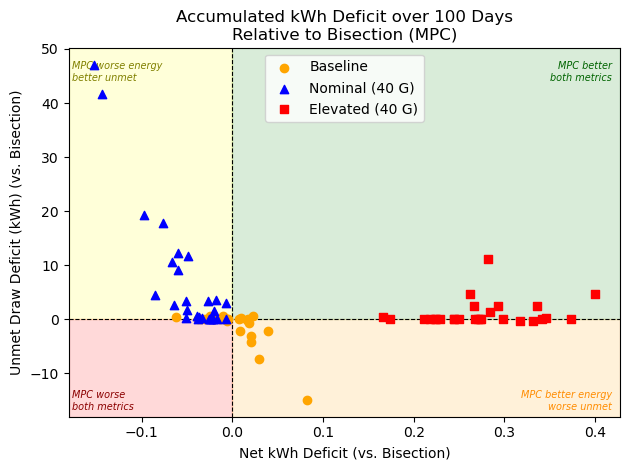

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots()

# --- Quadrant shading ---
# Get axis limits first (use data range + buffer)
x_data = np.concatenate([
    daily_kWh[:,0] - daily_kWh[:,3],
    daily_kWh[:,1] - daily_kWh[:,3],
    daily_kWh[:,2] - daily_kWh[:,3]
])
y_data = np.concatenate([
    unmet_draws[:,0] - unmet_draws[:,3],
    unmet_draws[:,1] - unmet_draws[:,3],
    unmet_draws[:,2] - unmet_draws[:,3]
])

pad = 0.05
x_min, x_max = x_data.min(), x_data.max()
y_min, y_max = y_data.min(), y_data.max()
x_range = x_max - x_min
y_range = y_max - y_min
xlim = (x_min - pad * x_range, x_max + pad * x_range)
ylim = (y_min - pad * y_range, y_max + pad * y_range)

alpha = 0.15

# Q1 (x>0, y>0): Other uses MORE energy AND has MORE unmet demand → GREEN (bisection best)
ax.fill_between([0, xlim[1]], 0, ylim[1], color='green', alpha=alpha)

# Q2 (x<0, y>0): Other saves energy BUT has MORE unmet demand → YELLOW
ax.fill_between([xlim[0], 0], 0, ylim[1], color='yellow', alpha=alpha)

# Q3 (x<0, y<0): Other saves energy AND has LESS unmet demand → RED (bisection worst)
ax.fill_between([xlim[0], 0], ylim[0], 0, color='red', alpha=alpha)

# Q4 (x>0, y<0): Other uses MORE energy BUT has LESS unmet demand → ORANGE
ax.fill_between([0, xlim[1]], ylim[0], 0, color='orange', alpha=alpha)

ax.set_xlim(xlim)
ax.set_ylim(ylim)

# --- Scatter plots ---
ax.scatter(daily_kWh[:,0] - daily_kWh[:,3], unmet_draws[:,0] - unmet_draws[:,3],
           label="Baseline", color="orange", zorder=5)
ax.scatter(daily_kWh[:,1] - daily_kWh[:,3], unmet_draws[:,1] - unmet_draws[:,3],
           label="Nominal (40 G)", color="blue", marker="^", zorder=5)
ax.scatter(daily_kWh[:,2] - daily_kWh[:,3], unmet_draws[:,2] - unmet_draws[:,3],
           label="Elevated (40 G)", color="red", marker="s", zorder=5)

# --- Reference lines ---
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# --- Quadrant labels ---
ax.text(xlim[1]*0.98, ylim[1]*0.95, "MPC better\nboth metrics",
        ha='right', va='top', fontsize=7, color='darkgreen', style='italic')
ax.text(xlim[0]*0.98, ylim[1]*0.95, "MPC worse energy\nbetter unmet",
        ha='left', va='top', fontsize=7, color='olive', style='italic')
ax.text(xlim[0]*0.98, ylim[0]*0.95, "MPC worse\nboth metrics",
        ha='left', va='bottom', fontsize=7, color='darkred', style='italic')
ax.text(xlim[1]*0.98, ylim[0]*0.95, "MPC better energy\nworse unmet",
        ha='right', va='bottom', fontsize=7, color='darkorange', style='italic')
# --- Labels & legend ---
ax.set_xlabel("Net kWh Deficit (vs. Bisection)")
ax.set_ylabel("Unmet Draw Deficit (kWh) (vs. Bisection)")
ax.set_title("Accumulated kWh Deficit over 100 Days\nRelative to Bisection (MPC)")
ax.legend()

plt.tight_layout()
plt.show()

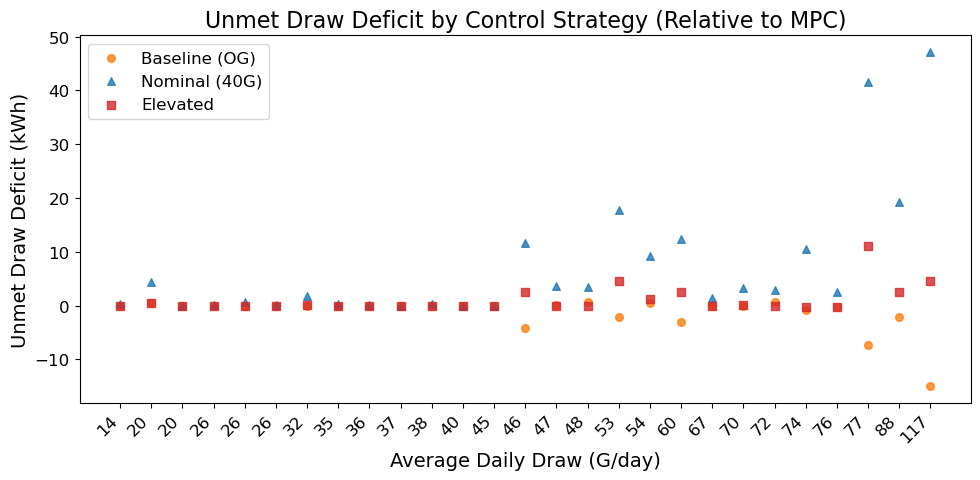

In [38]:
import numpy as np
import matplotlib.pyplot as plt

draw_levels = np.unique(avg_draw_g)
draw_labels = [int(round(g)) for g in draw_levels]

# Scenario differences
diffs = {
    "Baseline (OG)": unmet_draws[:,0] - unmet_draws[:,3],
    "Nominal (40G)": unmet_draws[:,1] - unmet_draws[:,3],
    "Elevated": unmet_draws[:,2] - unmet_draws[:,3],
}

markers = {
    "Baseline (OG)": "o",
    "Nominal (40G)": "^",
    "Elevated": "s",
}

colors = {
    "Baseline (OG)": "tab:orange",
    "Nominal (40G)": "tab:blue",
    "Elevated": "tab:red",
}

plt.figure(figsize=(10, 5))

# small horizontal offsets so dots don’t overlap
offsets = np.linspace(0,0, len(diffs))

for (label, data), dx in zip(diffs.items(), offsets):
    for i, g in enumerate(draw_levels):
        y = data[avg_draw_g == g]
        x = np.full_like(y, i + 1 + dx, dtype=float)
        plt.scatter(x, y,
                    marker=markers[label],
                    color=colors[label],
                    s=30,
                    alpha=0.8,
                    label=label if i == 0 else None)

plt.xticks(range(1, len(draw_labels) + 1), draw_labels, rotation=45, ha="right")
plt.xlabel("Average Daily Draw (G/day)")
plt.ylabel("Unmet Draw Deficit (kWh)")
plt.title("Unmet Draw Deficit by Control Strategy (Relative to MPC)")
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
import numpy as np

arr        = np.array(unmet_draws)
daily_arr  = np.array(daily_kWh)
if daily_arr.ndim == 1:
    daily_arr = daily_arr.reshape(-1, 1)
net        = np.array(net_savings)
if net.ndim > 1:
    net = net.reshape(len(net), -1)[:, 0]

tank_groups = {"50": [], "60": [], "80": []}
for i, site in enumerate(sites_arr):
    if site in sites_50:
        tank_groups["50"].append(i)
    elif site in sites_60:
        tank_groups["60"].append(i)
    elif site in sites_80:
        tank_groups["80"].append(i)

unmet_labels = ["Baseline (50/60/80g)", "Baseline (40g)", "Elevated Setpoint", "Bisection"]
kWh_labels   = ["Baseline (50/60/80g)", "Baseline (40g)", "Elevated Setpoint", "Bisection"]

for tank, indices in tank_groups.items():
    print(f"\n{'='*55}")
    print(f"  TANK SIZE: {tank} Gallon  (n={len(indices)} sites)")
    print(f"{'='*55}")

    # --- Unmet Demand ---
    print("\n  Unmet Demand (kWh)")
    print(f"  {'Strategy':<25} {'Mean':>8} {'Median':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
    print(f"  {'-'*65}")
    for i, lbl in enumerate(unmet_labels):
        vals = arr[indices, i]
        print(f"  {lbl:<25} {vals.mean():>8.2f} {np.median(vals):>8.2f} "
              f"{vals.std():>8.2f} {vals.min():>8.2f} {vals.max():>8.2f}")

    # --- Daily kWh ---
    print("\n  Daily kWh Consumption")
    print(f"  {'Strategy':<25} {'Mean':>8} {'Median':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
    print(f"  {'-'*65}")
    for i, lbl in enumerate(kWh_labels):
        vals = daily_arr[indices, i]
        print(f"  {lbl:<25} {vals.mean():>8.2f} {np.median(vals):>8.2f} "
              f"{vals.std():>8.2f} {vals.min():>8.2f} {vals.max():>8.2f}")

    # --- Net Savings ---
    net_vals = net[indices] * 100
    print(f"\n  Net Savings vs Elevated Setpoint (%)")
    print(f"  Mean:   {net_vals.mean():>6.2f}%")
    print(f"  Median: {np.median(net_vals):>6.2f}%")
    print(f"  Std:    {net_vals.std():>6.2f}%")
    print(f"  Min:    {net_vals.min():>6.2f}%")
    print(f"  Max:    {net_vals.max():>6.2f}%")


  TANK SIZE: 50 Gallon  (n=5 sites)

  Unmet Demand (kWh)
  Strategy                      Mean   Median      Std      Min      Max
  -----------------------------------------------------------------
  Baseline (50/60/80g)          0.13     0.00     0.27     0.00     0.67
  Baseline (40g)                0.78     0.12     1.32     0.00     3.40
  Elevated Setpoint             0.00     0.00     0.00     0.00     0.00
  Bisection                     0.00     0.00     0.00     0.00     0.00

  Daily kWh Consumption
  Strategy                      Mean   Median      Std      Min      Max
  -----------------------------------------------------------------
  Baseline (50/60/80g)          1.68     1.65     0.16     1.50     1.91
  Baseline (40g)                1.66     1.64     0.16     1.48     1.89
  Elevated Setpoint             1.96     1.93     0.18     1.76     2.21
  Bisection                     1.69     1.66     0.17     1.52     1.94

  Net Savings vs Elevated Setpoint (%)
  Mean:   

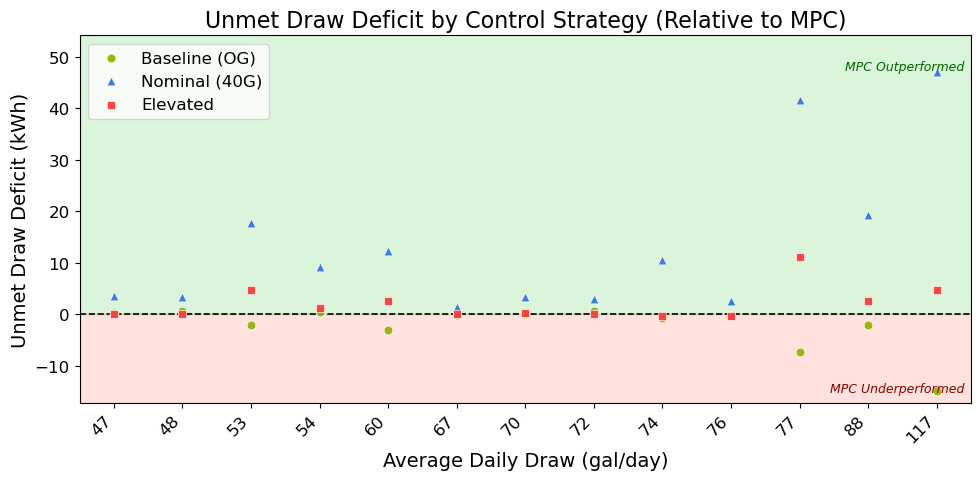

In [44]:
import numpy as np
import matplotlib.pyplot as plt

draw_levels = np.unique(avg_draw_g)
draw_labels = [int(round(g)) for g in draw_levels]

# Filter to >= 46 gal/day
mask = draw_levels >= 46
draw_levels_filtered = draw_levels[mask]
draw_labels_filtered = [int(round(g)) for g in draw_levels_filtered]

# Scenario differences
diffs = {
    "Baseline (OG)": unmet_draws[:,0] - unmet_draws[:,3],
    "Nominal (40G)": unmet_draws[:,1] - unmet_draws[:,3],
    "Elevated": unmet_draws[:,2] - unmet_draws[:,3],
}

markers = {
    "Baseline (OG)": "o",
    "Nominal (40G)": "^",
    "Elevated": "s",
}

# Darker/contrasting colors to stand out against green/red background
colors = {
    "Baseline (OG)": "#98B300",   # dark brown-orange
    "Nominal (40G)": "#3377E3",   # dark blue
    "Elevated": "#FF3C3C",        # dark purple
}

fig, ax = plt.subplots(figsize=(10, 5))

# Determine y range across all filtered data for shading
all_y = np.concatenate([
    data[np.isin(avg_draw_g, draw_levels_filtered)]
    for data in diffs.values()
])
y_min = min(all_y.min(), -0.5)
y_max = max(all_y.max(),  0.5)
x_min = 0.5
x_max = len(draw_levels_filtered) + 0.5

# Shade above y=0 green (good) and below y=0 red (bad)
ax.axhspan(0, y_max * 1.15, xmin=0, xmax=1, color="limegreen", alpha=0.18, zorder=0)
ax.axhspan(y_min * 1.15, 0, xmin=0, xmax=1, color="tomato",    alpha=0.18, zorder=0)

# Horizontal dashed line at y=0
ax.axhline(y=0, color="black", linestyle="--", linewidth=1.2, zorder=1)

# Plot scatter points
offsets = np.linspace(0, 0, len(diffs))
for (label, data), dx in zip(diffs.items(), offsets):
    for i, g in enumerate(draw_levels_filtered):
        y = data[avg_draw_g == g]
        x = np.full_like(y, i + 1 + dx, dtype=float)
        ax.scatter(x, y,
                   marker=markers[label],
                   color=colors[label],
                   edgecolors="white",
                   linewidths=0.5,
                   s=40,
                   alpha=0.95,
                   zorder=2,
                   label=label if i == 0 else None)

# Annotation labels for shaded regions
ax.text(x_max - 0.1, y_max * 1.05, "MPC Outperformed",
        ha="right", va="top", fontsize=9, color="darkgreen", style="italic")
ax.text(x_max - 0.1, y_min * 1.05, "MPC Underperformed",
        ha="right", va="bottom", fontsize=9, color="darkred", style="italic")

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min * 1.15, y_max * 1.15)
ax.set_xticks(range(1, len(draw_labels_filtered) + 1))
ax.set_xticklabels(draw_labels_filtered, rotation=45, ha="right")
ax.set_xlabel("Average Daily Draw (gal/day)")
ax.set_ylabel("Unmet Draw Deficit (kWh)")
ax.set_title("Unmet Draw Deficit by Control Strategy (Relative to MPC)")
ax.legend()
plt.tight_layout()
plt.show()

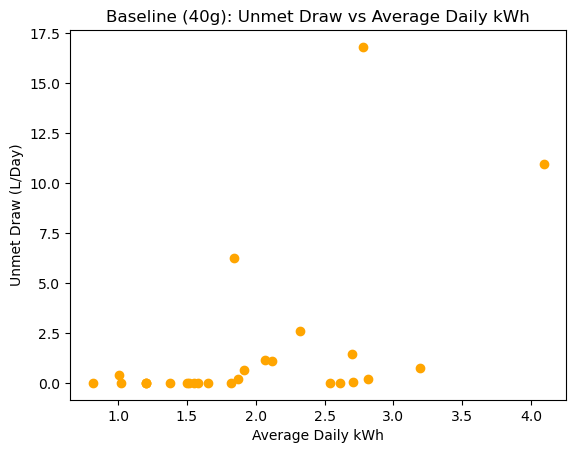

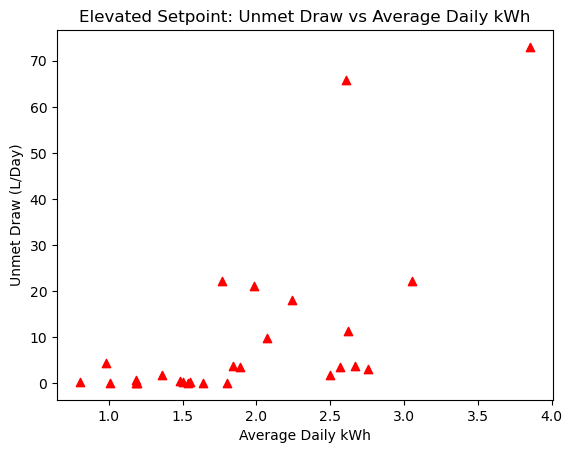

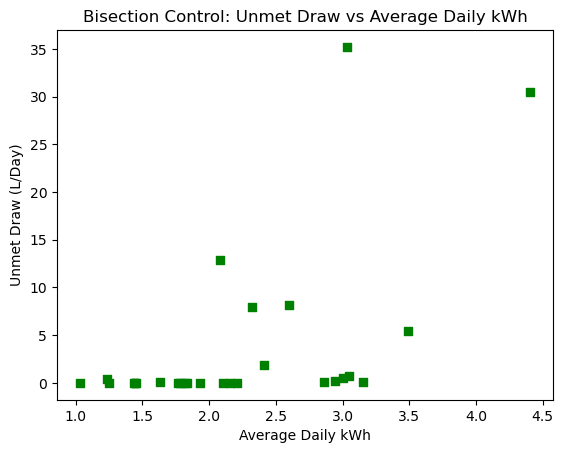

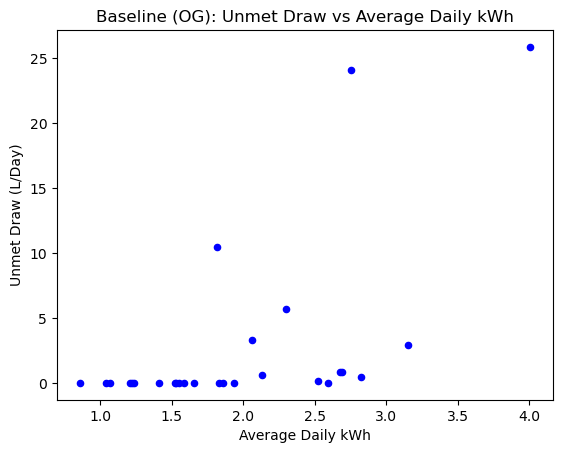

In [59]:
import matplotlib.pyplot as plt

# Plot 1: Baseline (40g)
plt.figure()
plt.scatter(daily_kWh[:, 0], unmet_draws[:, 0], color="orange")
plt.xlabel("Average Daily kWh")
plt.ylabel("Unmet Draw (L/Day)")
plt.title("Baseline (40g): Unmet Draw vs Average Daily kWh")
plt.show()

# Plot 2: Elevated Setpoint
plt.figure()
plt.scatter(daily_kWh[:, 1], unmet_draws[:, 1], color="red", marker="^")
plt.xlabel("Average Daily kWh")
plt.ylabel("Unmet Draw (L/Day)")
plt.title("Elevated Setpoint: Unmet Draw vs Average Daily kWh")
plt.show()

# Plot 3: Bisection
plt.figure()
plt.scatter(daily_kWh[:, 2], unmet_draws[:, 2], color="green", marker="s")
plt.xlabel("Average Daily kWh")
plt.ylabel("Unmet Draw (L/Day)")
plt.title("Bisection Control: Unmet Draw vs Average Daily kWh")
plt.show()

# Plot 4: Baseline (OG)
plt.figure()
plt.scatter(daily_kWh[:, 3], unmet_draws[:, 3], color="blue", s=20)
plt.xlabel("Average Daily kWh")
plt.ylabel("Unmet Draw (L/Day)")
plt.title("Baseline (OG): Unmet Draw vs Average Daily kWh")
plt.show()

In [ ]:
avg_draw_g = avg_draw_arr * 0.264172 # Convert L to gallons

#scatter plot b/w net savings and daily L/day
plt.scatter(avg_draw_g, net_savings)
plt.xlabel("Average Water Draw (G/Day)")
plt.ylabel("Bisection Net Savings (%)") #Compared to elevated setpoint
plt.title("Savings relationship for Site HPWH")

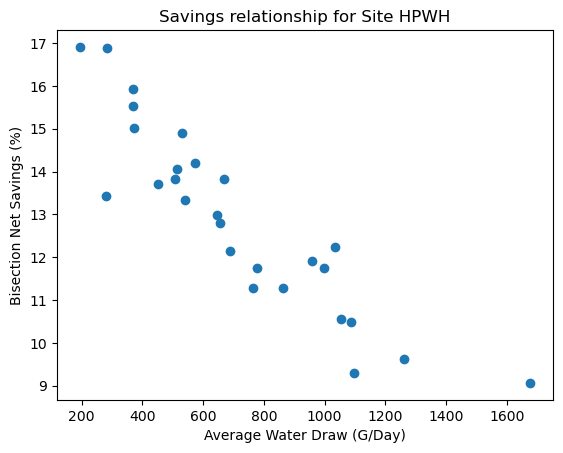

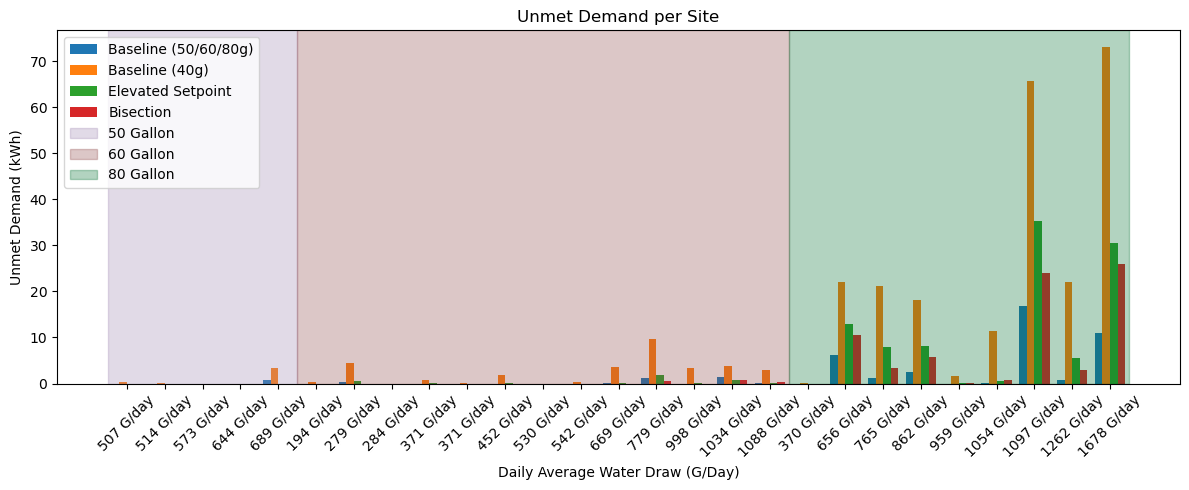

C:\Users\janel\AppData\Local\Temp\ipykernel_23772\3243882792.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(site_labels, rotation=45)


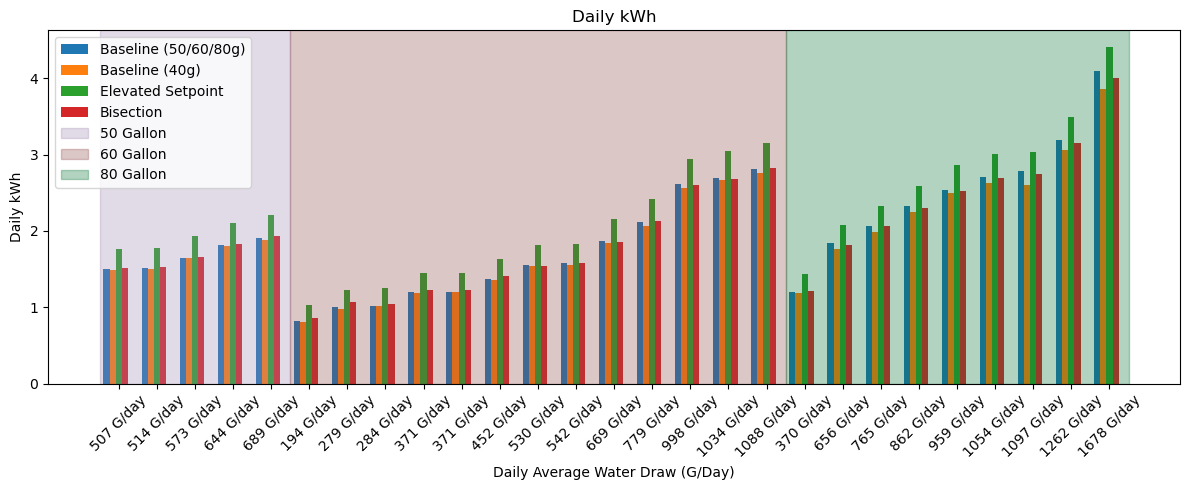

In [ ]:
#Bar graph comparisons
import matplotlib.pyplot as plt
import numpy as np

avg_draw_g = avg_draw_arr * 0.264172 # Convert L to gallons

#scatter plot b/w net savings and daily L/day
plt.scatter(avg_draw_g, net_savings)
plt.xlabel("Average Water Draw (G/Day)")
plt.ylabel("Bisection Net Savings (%)") #Compared to elevated setpoint
plt.title("Savings relationship for Site HPWH")

def add_group_shading(ax, sites_arr):

    start = 0
    current_group = None

    def get_group(site):
        if site in sites_50:
            return "50"
        elif site in sites_60:
            return "60"
        elif site in sites_80:
            return "80"

    for i, site in enumerate(sites_arr):
        group = get_group(site)

        if current_group is None:
            current_group = group

        if group != current_group:
            # shade previous block
            shade_block(ax, start, i-1, current_group)
            start = i
            current_group = group

    # Shade final block
    shade_block(ax, start, len(sites_arr)-1, current_group)


color50 = "#9D85B0"
color60 = "#8C4646"
color80 = "#016E30"
patch_alpha = 0.3

def shade_block(ax, start, end, group):
    colors = {
        "50": color50,
        "60": color60,
        "80": color80
    }
    ax.axvspan(start-0.5, end+0.5,
               color=colors[group],
               alpha=patch_alpha)



import matplotlib.pyplot as plt
import numpy as np

# --- Plot 1: unmet_draws (clustered bars per site) ---
arr = np.array(unmet_draws)
if arr.size == 0:
    raise ValueError("`unmet_draws` is empty; run the previous cell that populates it first.")
if arr.ndim == 1:
    arr = arr.reshape(-1, 1)

n_sites, n_values = arr.shape
x = np.arange(n_sites)               # site index positions
bar_width = 0.8 / max(1, n_values)   # width of each bar cluster
offset = (bar_width * (n_values - 1)) / 2

# Friendly default labels for the 4 expected columns; fall back if shape differs
default_labels = ["Baseline (50/60/80g)", "Baseline (40g)", "Elevated Setpoint", "Bisection"]
if n_values == len(default_labels):
    labels = default_labels
else:
    labels = [f"value {i}" for i in range(n_values)]

plt.figure(figsize=(12, 5))
for i in range(n_values):
    plt.bar(x + i * bar_width - offset, arr[:, i],
            width=bar_width,
            label=labels[i])

# X ticks correspond to each site
# Create combined labels with daily draw underneath
site_labels = [f"{draw:.0f} G/day"
               for draw in avg_draw_g]


plt.xticks(x, site_labels, rotation=45)

#plt.xticks(x, sites, rotation=45)

plt.xlabel("Daily Average Water Draw (G/Day)")
plt.ylabel("Unmet Demand (kWh)")
plt.title("Unmet Demand per Site")
plt.tight_layout()
plt.legend()


import matplotlib.patches as mpatches

patches = [
    mpatches.Patch(color=color50, alpha=patch_alpha, label="50 Gallon"),
    mpatches.Patch(color=color60, alpha=patch_alpha, label="60 Gallon"),
    mpatches.Patch(color=color80, alpha=patch_alpha, label="80 Gallon")
]

add_group_shading(plt.gca(), sites_arr)

ax = plt.gca()
handles, labels_existing = ax.get_legend_handles_labels()

ax.legend(
    handles=handles + patches,
    loc="upper left"
)

plt.show()

# --- Plot 2: daily_kWh (bars) + net_savings (%) as bars on secondary y-axis ---
# Convert daily_kWh and net_savings to arrays (robust handling of nested lists)
daily_arr = np.array(daily_kWh)
if daily_arr.size == 0:
    raise ValueError("`daily_kWh` is empty; run the previous cell that populates it first.")
if daily_arr.ndim == 1:
    daily_arr = daily_arr.reshape(-1, 1)

net = np.array(net_savings)
# net_savings may be a list of single-value lists (e.g., [[0.1],[0.2]]); flatten safely
if net.ndim > 1:
    net = net.reshape(len(net), -1)[:, 0]

# Ensure lengths match
if daily_arr.shape[0] != len(net):
    raise ValueError("Number of sites in `daily_kWh` and `net_savings` do not match")

# We'll create (n_daily_cols + 1) bars per cluster where the last bar is net savings (shown on ax2)
n_daily_cols = daily_arr.shape[1]
n_total = n_daily_cols + 1
bar_width2 = 0.8 / max(1, n_total)
offset2 = (bar_width2 * (n_total - 1)) / 2

fig, ax = plt.subplots(figsize=(12, 5))
# Plot daily kWh bars on primary axis
kWh_labels = ["Baseline (50/60/80g)", "Baseline (40g)", "Elevated Setpoint", "Bisection"]

for i in range(n_daily_cols):
    ax.bar(x + i * bar_width2 - offset2, daily_arr[:, i], width=bar_width2, label=kWh_labels[i])

# Secondary axis for net savings bars (percentage)
#ax2 = ax.twinx()
net_percent = net * 100.0
# Position net bars as the last bar in the cluster
net_positions = x + n_daily_cols * bar_width2 - offset2
#ax2.bar(net_positions, net_percent, width=bar_width2, color='purple', alpha=0.7, label='Net savings (%)')

# Labels and ticks


ax.set_xticklabels(site_labels, rotation=45)

ax.set_xticks(x)
#ax.set_xticklabels(sites, rotation=45)
ax.set_xlabel("Daily Average Water Draw (G/Day)")
ax.set_ylabel("Daily kWh")
#ax2.set_ylabel("Net savings (%)",color='purple')
#ax2.tick_params(axis='y', labelcolor='purple')
#ax2.set_ylim(0, 50)
ax.set_title("Daily kWh")

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1, labels1, loc='upper left')

add_group_shading(plt.gca(), sites_arr)

ax2 = plt.gca()
handles, labels_existing = ax2.get_legend_handles_labels()

ax2.legend(
    handles=handles + patches,
    loc="upper left"
)

fig.tight_layout()
plt.show()


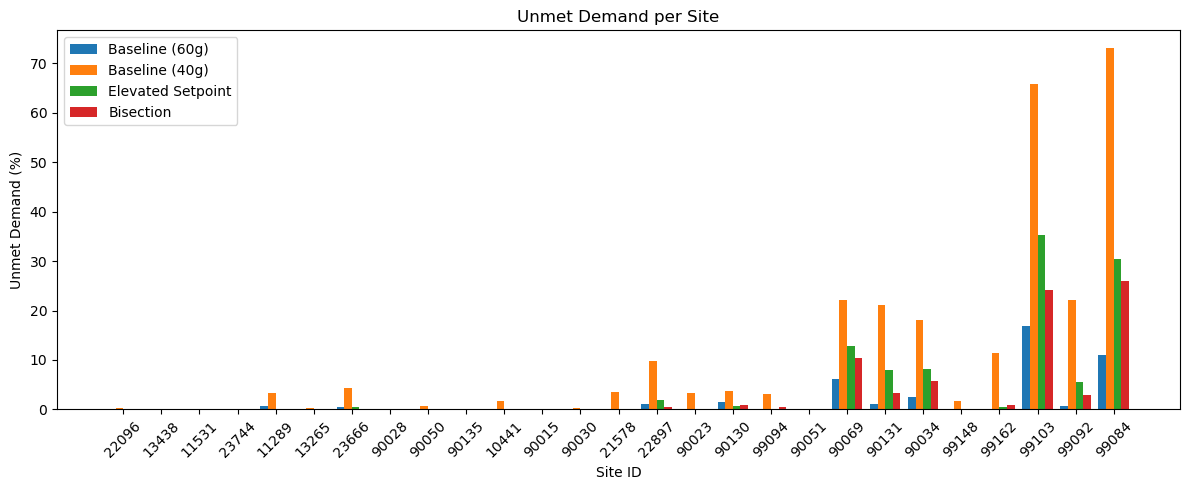

AttributeError: 'Axes' object has no attribute 'set_xticklab'

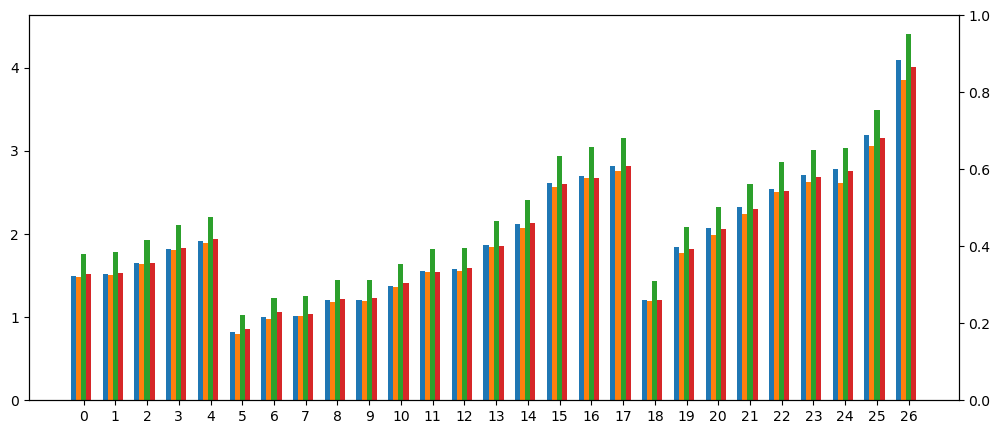

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# --- Plot 1: unmet_draws (clustered bars per site) ---
arr = np.array(unmet_draws)
if arr.size == 0:
    raise ValueError("`unmet_draws` is empty; run the previous cell that populates it first.")
if arr.ndim == 1:
    arr = arr.reshape(-1, 1)

n_sites, n_values = arr.shape
x = np.arange(n_sites)               # site index positions
bar_width = 0.8 / max(1, n_values)   # width of each bar cluster
offset = (bar_width * (n_values - 1)) / 2

# Friendly default labels for the 4 expected columns; fall back if shape differs
default_labels = ["Baseline (60g)", "Baseline (40g)", "Elevated Setpoint", "Bisection"]
if n_values == len(default_labels):
    labels = default_labels
else:
    labels = [f"value {i}" for i in range(n_values)]

plt.figure(figsize=(12, 5))
for i in range(n_values):
    plt.bar(x + i * bar_width - offset, arr[:, i],
            width=bar_width,
            label=labels[i])

# X ticks correspond to each site
plt.xticks(x, sites, rotation=45)
plt.xlabel("Site ID")
plt.ylabel("Unmet Demand (%)")
plt.title("Unmet Demand per Site")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: daily_kWh (bars) + net_savings (%) as bars on secondary y-axis ---
# Convert daily_kWh and net_savings to arrays (robust handling of nested lists)
daily_arr = np.array(daily_kWh)
if daily_arr.size == 0:
    raise ValueError("`daily_kWh` is empty; run the previous cell that populates it first.")
if daily_arr.ndim == 1:
    daily_arr = daily_arr.reshape(-1, 1)

net = np.array(net_savings)
# net_savings may be a list of single-value lists (e.g., [[0.1],[0.2]]); flatten safely
if net.ndim > 1:
    net = net.reshape(len(net), -1)[:, 0]

# Ensure lengths match
if daily_arr.shape[0] != len(net):
    raise ValueError("Number of sites in `daily_kWh` and `net_savings` do not match")

# We'll create (n_daily_cols + 1) bars per cluster where the last bar is net savings (shown on ax2)
n_daily_cols = daily_arr.shape[1]
n_total = n_daily_cols + 1
bar_width2 = 0.8 / max(1, n_total)
offset2 = (bar_width2 * (n_total - 1)) / 2

fig, ax = plt.subplots(figsize=(12, 5))
# Plot daily kWh bars on primary axis
kWh_labels = ["Baseline (60g)", "Baseline (40g)", "Elevated Setpoint", "Bisection"]

for i in range(n_daily_cols):
    ax.bar(x + i * bar_width2 - offset2, daily_arr[:, i], width=bar_width2, label=kWh_labels[i])

# Secondary axis for net savings bars (percentage)
ax2 = ax.twinx()
net_percent = net * 100.0
# Position net bars as the last bar i#n the cluster
net_positions = x + n_daily_cols * bar_width2 - offset2
#ax2.bar(net_positions, net_percent, width=bar_width2, color='purple', alpha=0.7, label='Net savings (%)')

# Labels and ticks
ax.set_xticks(x)
ax.set_xticklab#els(sites, rotation=45)
ax.set_xlabel("Site ID")#
ax.set_ylabel("Daily kWh")
#ax2.set_ylabel("Ne#t savings (%)",color='purple')
#ax2.tick_parm='purple')
#ax2.set_ylim(0, 50)
ax.set_title("Daily kWh and Net Savings per Site")
#
# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout()
plt.show()


In [12]:
site_number = 90023
setpoint_default = 51.5
a = pd.read_csv(f'constant_setpoint_90023\\output_site_{site_number}_{setpoint_default}_constant_setpoint_{water_nodes}.csv')
constant = pd.read_csv(f"constant_setpoint_{site}\\output_site_{site}_51_5.56_12.csv")

print(get_daily_kWh(a), get_daily_kWh(constant))
print(return_unmet_draws(a), return_unmet_draws(constant))


1.527818856396974 1.5122553481822978
0.4167631396156518 0.5093771706413521


In [ ]:
def pareto_frontier(x_vals, y_vals):
    points = sorted(zip(x_vals, y_vals), key=lambda x: (x[0], x[1]))  # Sort by energy
    pareto_x, pareto_y = [], []
    min_y = float('inf')

    for x, y in points:
        if y < min_y:  # Keep only points with lower y than previously seen
            pareto_x.append(x)
            pareto_y.append(y)
            min_y = y
    return pareto_x, pareto_y


def get_daily_kWh(data):
    energy = data["Water Heating Electric Power"] #15 minute intervals of kwh
    day_sums = energy.groupby(energy.index // 96).sum().tolist()
    return (np.mean(day_sums))

def return_unmet_draws(data, min = 40.6):
    # draws = data["Hot Water Outlet Temperature (C)"].values
    # cold_water_draws = sum(float(i) < min for i in draws)
    # return cold_water_draws/len(draws) * 100
    return (data["Hot Water Unmet Demand (kWh)"].sum())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

site = "90023"
min_temp = 49 #Unmet demand cutoff
bisection_temp = 49
#percent = pd.read_csv(f"site_output\\output_site_{site}_bisectioncontrol_ud_{bisection_temp}_12_99_percentile.csv")
weeks = pd.read_csv(f"site_output\\output_site_{site}_bisectioncontrol_ud_{bisection_temp}_12_rolling avg.csv")
control = pd.read_csv(f"site_output\\output_site_{site}_bisectioncontrol_ud_{bisection_temp}_12_perfect.csv")
constant = pd.read_csv(f"constant_setpoint_{site}\\output_site_{site}_51_5.56_12.csv")

# print(return_unmet_draws(percent, min_temp), get_daily_kWh(percent), np.sum(percent["Water Heating Electric Power"]))
# print(return_unmet_draws(weeks, min_temp),  get_daily_kWh(weeks), np.sum(percent["Water Heating Electric Power"]))
# print(return_unmet_draws(control, min_temp), get_daily_kWh(control), np.sum(control["Water Heating Electric Power"]))
# print(return_unmet_draws(constant, min_temp),  get_daily_kWh(constant), np.sum(constant["Water Heating Electric Power"]))

#pareto curve
min_setpoint = 49
max_setpoint = 60
setpoint_range = np.arange(min_setpoint , max_setpoint + 0.5, 0.5)
site_number = '90023'
water_nodes = 12
cold_water_gradient = []
net_energy_gradient = []
min_temps = [min_temp] #different unmet demand temperatures
for min_temp in min_temps:
    cold_water_draws = []
    net_energy = []
    for setpoint_default in setpoint_range: 
        withdraw_rate = pd.read_csv(f'constant_setpoint_90023\\output_site_{site_number}_{setpoint_default}_constant_setpoint_{water_nodes}.csv')


        cold = return_unmet_draws(withdraw_rate, min_temp)
        energy = withdraw_rate['Water Heating Electric Power']

        #sum 15 minute intervals into daily 
        daily_energy = []
        interval_length = 4 * 24 #4 intervals per hour
        daily_energy = get_daily_kWh(withdraw_rate)

        cold_water_draws.append(cold)
        
        net_energy.append(np.mean(daily_energy))
    cold_water_gradient .append(cold_water_draws)
    net_energy_gradient.append(net_energy)




# fig, ax1 = plt.subplots()

# # Primary y-axis (Unmet Demand %)
# ax1.plot(setpoint_range, cold_water_gradient, 'b-', label="Unmet Demand")
# ax1.set_xlabel("Setpoint (°C)")
# ax1.set_ylabel("Unmet Demand (%)", color='b')
# ax1.tick_params(axis='y', labelcolor='b')

# # Secondary y-axis (Energy in kWh)
# ax2 = ax1.twinx()
# ax2.plot(setpoint_range, net_energy, 'r-', label="Energy (kWh)")
# ax2.set_ylabel("Daily Energy (kWh)", color='r')
# ax2.tick_params(axis='y', labelcolor='r')

# # Optional: Add legends
# lines_1, labels_1 = ax1.get_legend_handles_labels()
# lines_2, labels_2 = ax2.get_legend_handles_labels()
# ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

# plt.title("Setpoint vs. Unmet Demand and Energy Use")
# plt.tight_layout()
# plt.show()


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.rcParams['font.size'] = 14  # Change 14 to your desired font size
for i in range(len(net_energy_gradient)):
    pareto_energy, pareto_demand = pareto_frontier(net_energy_gradient[i], cold_water_gradient[i])

    #plt.axvline(x=1.527, color='orange', linestyle='--', linewidth=2, label="Baseline Performance")
    # Plot the Pareto curve
    plt.plot(pareto_energy, pareto_demand, label=f"Constant Setpoint - Min Temp: {min_temps[i]}", linewidth=2)

    plt.plot(net_energy_gradient[i], cold_water_gradient[i], 'o', alpha=0.3)
    # Annotate each point with its setpoint
    for x, y, sp in zip(net_energy_gradient[i], cold_water_gradient[i], setpoint_range):
        if sp == 51.5:
            print(sp, x, y)
            plt.annotate(f"{sp:.1f}", (x, y),
                    textcoords="offset points", xytext=(4, 4), ha='left', fontsize=12, color='gray')
        
        else:
            plt.annotate(f"{sp:.1f}", (x, y),
                    textcoords="offset points", xytext=(4, 4), ha='left', fontsize=8, color='gray')
        
    plt.plot(get_daily_kWh(percent), return_unmet_draws(percent, min_temps[i]),  'o', label=f"Percentile Forecasting", markersize=12) #I want to label each instance here with its setpoint fr/setpoint_range
    plt.plot(get_daily_kWh(weeks), return_unmet_draws(weeks, min_temps[i]),  's', label=f"Two-Week Forecasting", markersize=8)
    plt.plot(get_daily_kWh(control), return_unmet_draws(control, min_temps[i]),  'D', label=f"Perfect Forecasting", markersize=8)

    #print(get_daily_kWh(percent), return_unmet_draws(percent, min_temps[i])) #I want to label each instance here with its setpoint fr/setpoint_range
    #print(get_daily_kWh(weeks), return_unmet_draws(weeks, min_temps[i]))
    #print(get_daily_kWh(control), return_unmet_draws(control, min_temps[i]))


print(return_unmet_draws(percent, min_temp), get_daily_kWh(percent), np.sum(percent["Water Heating Electric Power"]))
print(return_unmet_draws(weeks, min_temp),  get_daily_kWh(weeks), np.sum(percent["Water Heating Electric Power"]))
print(return_unmet_draws(control, min_temp), get_daily_kWh(control), np.sum(control["Water Heating Electric Power"]))
print(return_unmet_draws(constant, min_temp),  get_daily_kWh(constant), np.sum(constant["Water Heating Electric Power"]))

# Plot individual forecasting methods with markers


# Labels and formatting
plt.title("Bisection Method Performance", fontsize=16)
plt.ylabel("Unmet Demand (kWh)", fontsize=14)
plt.xlabel("Electricity Usage (kWh/Day)", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()

#plt.xlim(1.5, 1.57)
#plt.ylim(0, 10)
plt.show()


#plt.plot(setpoint_range, net_energy)
#plt.plot(setpoint_range, cold_water_draws)

FileNotFoundError: [Errno 2] No such file or directory: 'site_output\\output_site_90023_bisectioncontrol_ud_49_12_99_percentile.csv'

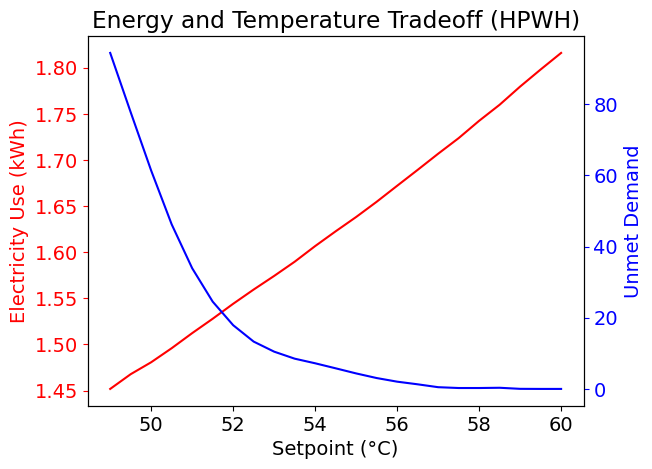

In [33]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Left y-axis: Electricity use (orange)
ax1.plot(setpoint_range, net_energy, color="red", label="Electricity Use (kWh)")
ax1.set_xlabel("Setpoint (°C)")
ax1.set_ylabel("Electricity Use (kWh)", color="red")
ax1.tick_params(axis='y', colors='red')

# Right y-axis: Unmet demand (blue)
ax2 = ax1.twinx()
ax2.plot(setpoint_range, cold_water_draws, color="blue", label="Unmet Demand")
ax2.set_ylabel("Unmet Demand", color="blue")
ax2.tick_params(axis='y', colors='blue')

# Title
plt.title("Energy and Temperature Tradeoff (HPWH)")

plt.show()


In [23]:
net_energy

[1.4517700395231508,
 1.4677468428414184,
 1.4807011108248245,
 1.4959132320125392,
 1.5122553481822978,
 1.527818856396974,
 1.5440651208533864,
 1.5595057097882052,
 1.5742700460245185,
 1.589651524253913,
 1.6066233799123313,
 1.6226276198742502,
 1.6381522857599562,
 1.654639597561314,
 1.6719907541251338,
 1.68922175934471,
 1.7067194814784397,
 1.7236291757297941,
 1.742425596278913,
 1.7598298727489745,
 1.7795280719590547,
 1.7980336869733466,
 1.8160201644479306]

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load data for the selected site
site_number = 90159
baseline_40 = pd.read_csv(f'output_site_{site_number}_151(L)_12.csv')
elevated = pd.read_csv(f'output_site_{site_number}_151(L)_60.csv')
baseline_og = pd.read_csv(f'output_site_{site_number}_227(L)_12.csv')
bisection = pd.read_csv(f"output_site_{site_number}_bisectioncontrol_ud_49_12_rolling avg.csv")

# Series to plot
hot = baseline_40["Hot Water Outlet Temperature (C)"]
draw = baseline_40["Draw Data"]
# x-axis (use index; if you have a datetime index replace this with the datetime column)
x = np.arange(len(draw))

# Create figure and dual axes
fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis: hot water temperature
color_hot = "tab:red"
ax1.plot(x, hot, color=color_hot, label="Hot Water Outlet Temp (C)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature (°C)", color=color_hot)
ax1.tick_params(axis='y', labelcolor=color_hot)
ax1.grid(True, which='both', axis='x', linestyle='--', alpha=0.3)

# Right axis: draw data
ax2 = ax1.twinx()
color_draw = "tab:blue"
ax2.plot(x, draw, color=color_draw, linestyle='--', label="Draw Data (L/min)")
ax2.set_ylabel("Draw (L/min)", color=color_draw)
ax2.tick_params(axis='y', labelcolor=color_draw)
# Set a sensible upper limit so the draw axis isn't squashed (guard against zero-length)
if len(draw) > 0:
    ax2.set_ylim(0, max(draw.max() * 1.1, 1))

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title(f"Site {site_number} — Hot Water Outlet Temp and Draw Data")
fig.tight_layout()
day = 6
plt.xlim(96 * (day - 1), 96 * day)
plt.xlim(0, 672 * 4)
plt.show()
# map full-scale tick po1day

FileNotFoundError: [Errno 2] No such file or directory: 'output_site_90159_151(L)_12.csv'

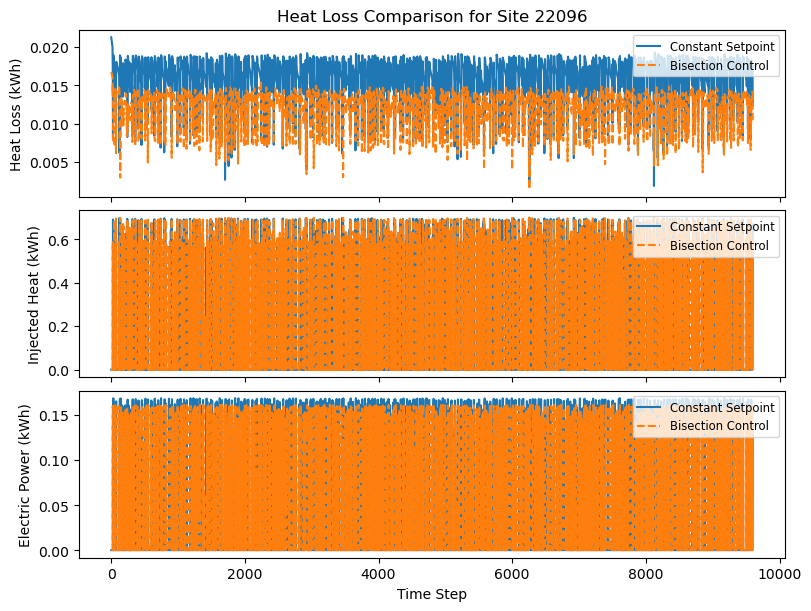

In [36]:
# Investigating Heat loss between two sites
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

site = 22096

constant = pd.read_csv(f'heat_loss\\output_site_{site}_151(L)_60.csv')
bisection = pd.read_csv(f'heat_loss\\output_site_{site}_bisectioncontrol_ud_49_12_rolling avg.csv')


# Compact 3-row figure
fig, (ax0, ax1, ax2) = plt.subplots(
    3, 1, figsize=(8, 6), sharex=True, constrained_layout=True
)

# --- Heat Loss ---
ax0.plot(constant["Hot Water Heat Loss (kWh)"], label="Constant Setpoint")
ax0.plot(bisection["Hot Water Heat Loss (kWh)"], label="Bisection Control", linestyle="--")
ax0.set_title(f"Heat Loss Comparison for Site {site}")
ax0.set_ylabel("Heat Loss (kWh)")
ax0.legend(loc="upper right", fontsize="small")

# --- Delivered Heat ---
ax1.plot(constant["Hot Water Heat Injected (kWh)"], label="Constant Setpoint")
ax1.plot(
    bisection["Hot Water Heat Injected (kWh)"],
    label="Bisection Control",
    linestyle="--"
)
ax1.set_ylabel("Injected Heat (kWh)")
ax1.legend(loc="upper right", fontsize="small")

# --- Electric Power ---
ax2.plot(constant["Water Heating Electric Power"], label="Constant Setpoint")
ax2.plot(bisection["Water Heating Electric Power"], label="Bisection Control", linestyle="--")
ax2.set_xlabel("Time Step")
ax2.set_ylabel("Electric Power (kWh)")
ax2.legend(loc="upper right", fontsize="small")

plt.show()


In [2]:
dt = 60 * 15  # seconds in each 15-minute interval
constant_loss_sum = np.sum(constant["Hot Water Heat Loss (kWh)"]) * dt
bisection_loss_sum = np.sum(bisection["Hot Water Heat Loss (kWh)"]) * dt
print(constant_loss_sum, bisection_loss_sum, 1 - bisection_loss_sum/constant_loss_sum)

constant_electric_sum = np.sum(constant["Water Heating Electric Power"]) * dt
bisection_electric_sum = np.sum(bisection["Water Heating Electric Power"]) * dt
print(constant_electric_sum, bisection_electric_sum, 1 - bisection_electric_sum/constant_electric_sum)

140547.33122912978 106041.8744810382 0.24550773356086308
283792.8537685437 253997.860934105 0.10498852398425418


22096
Bisection 0.11459527034066049 2.8221984548233894 282.2198454823389
Baseline (Elevated)  0.041671007396603815 3.1532539307615974 315.3253930761596
Net savings:  0.10498852398425418
Average Difference in Losses:  0.003994103176035879


In [36]:
#Comparing heat loss 
import pandas as pd
import numpy as np

def get_daily_kWh(data):
    energy = data["Water Heating Electric Power"] #15 minute intervals of kwh
    day_sums = energy.groupby(energy.index // 96).sum().tolist()
    return (np.mean(day_sums))

def return_unmet_draws(data, min = 40.6):
    #data["Hot Water Outlet Temperature (C)"] = (pd.to_numeric(data["Hot Water Outlet Temperature (C)"], errors="coerce"))
    draws = data["Hot Water Outlet Temperature (C)"].values
    cold_water_draws = sum(float(i) < min for i in draws)
    return cold_water_draws/len(draws) * 100

dt = 1 # seconds in each 15-minute interval
#E_electric = E_delivered + E_loss + other
def total_loss_kWh(data):
    # 15-minute intervals
    return np.sum(data["Hot Water Heat Loss (kWh)"]*dt) 

def total_electric_kWh(data):
    return np.sum(data["Hot Water Heat Injected (kWh)"]*dt)

def total_heat_pump_electric_kWh(data):
    return np.sum(data["Water Heating Electric Power"]*dt)
#sites = [22096]
sites = [ 22096, 13438, 11531, 23744,
11289,
13265,
23666,
90028,
90050,
90135,
10441,
90015,
90030
]


unmet_draws = []
daily_kWh = []
net_savings = []
avg_draw = []
net_injection_savings = []
net_loss_savings = []
for site_number in sites:
    print(site_number)
    #Comparing standard performance to 40 G bisection controller

    min_temp = 40.6

    elevated = pd.read_csv(f'heat_loss\\output_site_{site_number}_151(L)_60.csv')

    baseline_og = None
 
    bisection = pd.read_csv(f"heat_loss\\output_site_{site_number}_bisectioncontrol_ud_49_12_rolling avg.csv")

    print("Bisection", return_unmet_draws(bisection, min_temp), get_daily_kWh(bisection), np.sum(bisection["Water Heating Electric Power"])) #100 days
    print("Baseline (Elevated) ", return_unmet_draws(elevated, min_temp), get_daily_kWh(elevated), np.sum(elevated["Water Heating Electric Power"])) #365 days
    print("Net savings: ", 1 - np.sum(bisection["Water Heating Electric Power"])/np.sum(elevated["Water Heating Electric Power"]))
    draw = elevated['Draw Data']
    draw = draw[:-95] #removing last day to keep indices exact
    daily_avg = np.sum(np.asarray(draw).reshape(-1, 96), axis=1)
    avg_draw.append(daily_avg.mean()) #avg L per day
    unmet_draws.append([return_unmet_draws(elevated, min_temp), return_unmet_draws(bisection, min_temp) ])
    daily_kWh.append([get_daily_kWh(elevated),get_daily_kWh(bisection)  ])
    net_savings.append(np.sum(elevated["Water Heating Electric Power"]) - np.sum(bisection["Water Heating Electric Power"]) )
    #print(return_unmet_draws(bisection_ideal, min_temp), get_daily_kWh(bisection_ideal), np.sum(bisection_ideal["Water Heating Electric Power"])) #100 days
 

    #Compute total loss and kwh of elevated and bisection
    elevated_loss_kWh   = total_loss_kWh(elevated)
    bisection_loss_kWh  = total_loss_kWh(bisection)
    elevated_delivered = np.sum(elevated["Hot Water Delivered (kWh)"]*dt) 
    bisection_delivered = np.sum(bisection["Hot Water Delivered (kWh)"]*dt) 

    elevated_elec_kWh  = total_electric_kWh(elevated)
    bisection_elec_kWh = total_electric_kWh(bisection)

    # Absolute savings
    total_savings_kWh = elevated_elec_kWh - bisection_elec_kWh
    loss_savings_kWh  = elevated_loss_kWh - bisection_loss_kWh

    net_injection_savings.append(elevated_elec_kWh - bisection_elec_kWh)
    net_loss_savings.append((elevated_loss_kWh - bisection_loss_kWh))

    print("Elevated Electric = ", elevated_elec_kWh, " (Injected) ~ ", elevated_delivered, " (delivered) + ", elevated_loss_kWh, "(loss) = ", elevated_delivered + elevated_loss_kWh, " unaccounted: ", elevated_elec_kWh - (elevated_delivered + elevated_loss_kWh))
    print("Bisection Electric = ", bisection_elec_kWh, " (Injected) ~ ", bisection_delivered, " (delivered) + ", bisection_loss_kWh, "(loss) = ", bisection_delivered + bisection_loss_kWh, " unaccounted: ", bisection_elec_kWh - (bisection_delivered + bisection_loss_kWh))
    print(f"Difference in Losses (kWh): {total_savings_kWh:.2f}")
    print(f"Difference in Electric (kWh): {loss_savings_kWh:.2f}")
    print(f"Injection Savings (kWh): {(1 - bisection_elec_kWh/elevated_elec_kWh)* 100} %")
    print(f"Electric Savings (kWh): {(1 - total_heat_pump_electric_kWh(bisection)/total_heat_pump_electric_kWh(elevated))* 100} %")
    print(f"Loss Savings (kWh): {(1 - bisection_loss_kWh/elevated_loss_kWh) * 100} %")





22096
Bisection 0.11459527034066049 2.8221984548233894 282.2198454823389
Baseline (Elevated)  0.041671007396603815 3.1532539307615974 315.3253930761596
Net savings:  0.10498852398425418
Elevated Electric =  1279.7520712736293  (Injected) ~  1125.8736314034363  (delivered) +  156.16370136569975 (loss) =  1282.0373327691361  unaccounted:  -2.285261495506802
Bisection Electric =  1239.9895873368587  (Injected) ~  1125.5398058546484  (delivered) +  117.82430497893134 (loss) =  1243.3641108335798  unaccounted:  -3.3745234967211672
Difference in Losses (kWh): 39.76
Difference in Electric (kWh): 38.34
Injection Savings (kWh): 3.107045874690273 %
Electric Savings (kWh): 10.498852398425418 %
Loss Savings (kWh): 24.55077335608631 %
13438
Bisection 0.020835503698301908 2.595917143168224 259.5917143168223
Baseline (Elevated)  0.12501302218981145 2.9411453849849334 294.1145384984933
Net savings:  0.11737884280701028
Elevated Electric =  1181.2258030298872  (Injected) ~  1030.5633414140912  (deliver

In [22]:
avg_draw

[287.53821414141413,
 263.60218727272724,
 273.1995398989899,
 51.12215323232324,
 98.03829535353535,
 97.96182242424243,
 143.15732363636363,
 74.9434707070707,
 119.41247909090909,
 73.83461323232324,
 176.6142302020202,
 205.6739433333333,
 139.90722414141416]

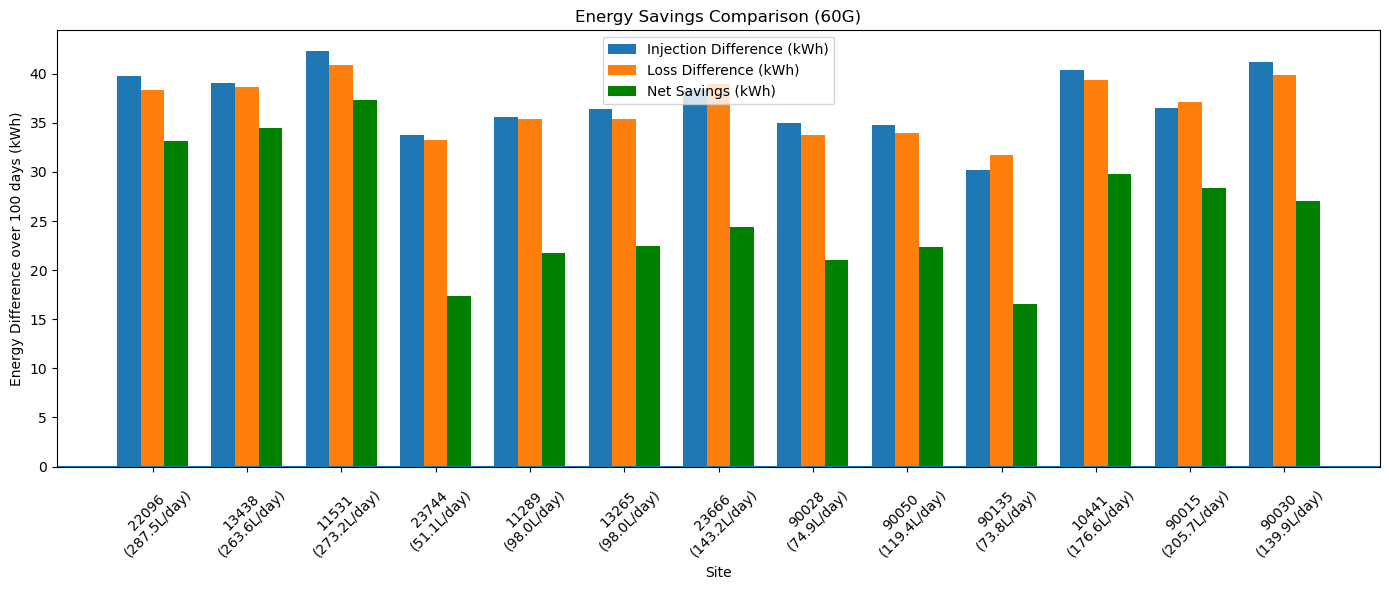

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(sites))
width = 0.25

fig, ax1 = plt.subplots(figsize=(14, 6))

# Left axis: kWh
ax1.bar(x - width, net_injection_savings, width, label="Injection Difference (kWh)")
ax1.bar(x,         net_loss_savings,      width, label="Loss Difference (kWh)")
ax1.bar(x + width, net_savings, width, label="Net Savings (kWh)", color='green')

ax1.axhline(0)
ax1.set_ylabel("Energy Difference over 100 days (kWh)")
ax1.set_xlabel("Site")

# Title & ticks
ax1.set_title("Energy Savings Comparison (60G)")
ax1.set_xticks(x)
ax1.set_xticklabels([f"{site}\n({avg_draw[i]:.1f}L/day)" for i, site in enumerate(sites)], rotation=45) #add {avg_draw}

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles1, labels1, loc="best")

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Stat comparison for 60 G tanks')

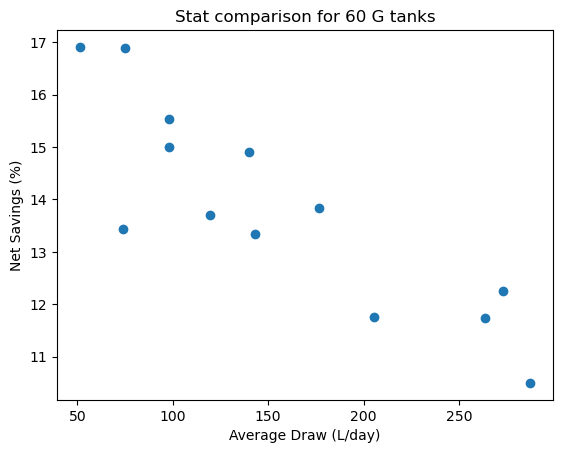

In [15]:
plt.scatter(avg_draw, net_savings)
plt.xlabel("Average Draw (L/day)")
plt.ylabel("Net Savings (%)")
plt.title("Stat comparison for 60 G tanks")

<BarContainer object of 13 artists>

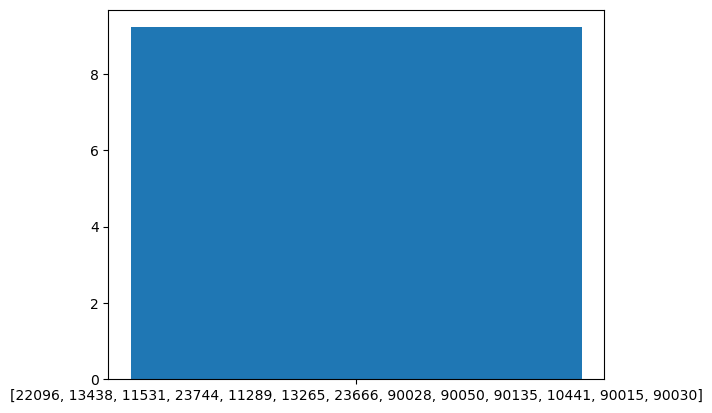